In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import scipy.stats as stat
from matplotlib.patches import Patch
import statsmodels.formula.api as smf

In [2]:
os.chdir('BehavioralDataAligned')

In [3]:
train = pd.DataFrame()
test = pd.DataFrame()
for subject in os.listdir():
    if 'behavioral_data.csv' in subject:
        subject_id = pd.read_csv(subject)['ID'][0]
        sub = pd.read_csv(subject)
        sub_train = sub[sub['BlockNumber'] < 13]
        train = pd.concat([train, sub_train], ignore_index=True)
        sub_test = sub[sub['BlockNumber'] > 12]
        test = pd.concat([test, sub_test], ignore_index=True)
    
train['TargetCondition'] = train['TargetCondition'].map({1: 'frequent', 2: 'infrequent'})
test['TargetCondition'] = test['TargetCondition'].map({1: 'frequent', 2: 'infrequent'})

### Participants who don't have faster RT for frequent object in training

In [4]:
train_RT = train.groupby(['ID', 'TargetCondition'])[['RT']].mean().reset_index()
frequent = train_RT[train_RT['TargetCondition'] == 'frequent'].set_index('ID')['RT']
infrequent = train_RT[train_RT['TargetCondition'] == 'infrequent'].set_index('ID')['RT']

# Compare and find IDs where frequent RT > infrequent RT
no_learning_ids = frequent[frequent > infrequent].index.tolist()
no_learning_ids

[3, 13, 22, 23, 34, 36, 37, 41, 45, 49]

In [5]:
diff = infrequent - frequent
ranked_diff = diff.sort_values(ascending=True)
ids = ranked_diff.index.tolist()
valid_group_ids = ids[18:]
invalid_group_ids = ids[:18]

In [6]:
diff.mean(), diff.std()

(np.float64(71.43300905791438), np.float64(93.044928574661))

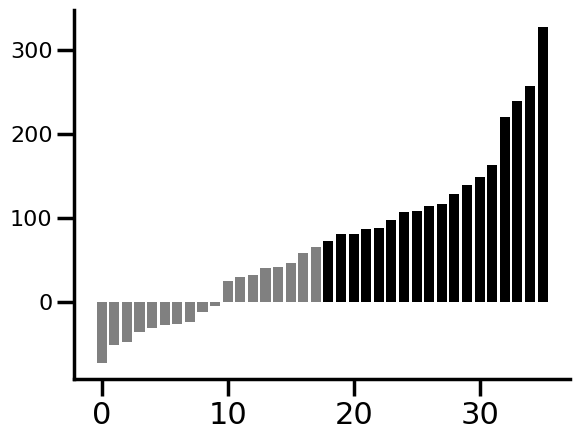

In [7]:
sns.set_context("poster", rc={"ytick.labelsize": 16})
plt.bar(x = range(len(ranked_diff)), height=ranked_diff, color = ['black' if id in valid_group_ids else 'grey' for id in ranked_diff.index])
sns.despine();
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/RT_diff.png', dpi=300)

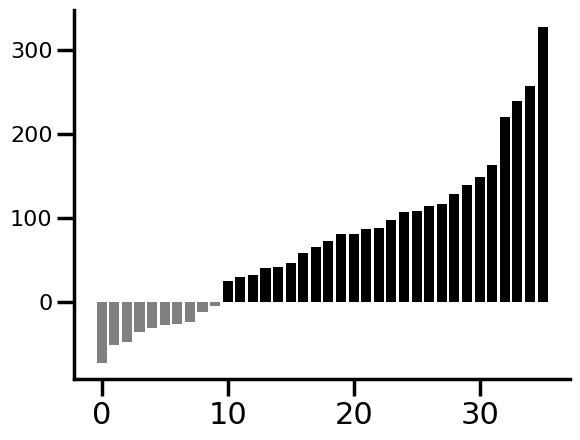

In [8]:
sns.set_context("poster", rc={"ytick.labelsize": 16})
plt.bar(x = range(len(ranked_diff)), height=ranked_diff, color = ['grey' if id in no_learning_ids else 'black' for id in ranked_diff.index])
sns.despine();

In [9]:
valid_group_ids

[29, 16, 42, 39, 2, 40, 26, 48, 38, 12, 19, 44, 21, 24, 20, 33, 14, 47]

In [10]:
invalid_group_ids

[41, 36, 45, 49, 23, 13, 22, 37, 34, 3, 7, 46, 30, 15, 31, 25, 10, 32]

### Overall stats

In [11]:
train['phase'] = 'train'
test['phase'] = 'test'
overall = pd.concat([train, test], ignore_index=True)

In [12]:
overall[['RT', 'Accuracy']].mean().reset_index()

,index,0
0,RT,749.639707
1,Accuracy,1.000000


In [13]:
overall.groupby('TargetCondition')['RT'].mean().reset_index()

,TargetCondition,RT
0,frequent,748.069353
1,infrequent,750.426734


In [14]:
overall.groupby('TargetCondition')['RT'].std().reset_index()

,TargetCondition,RT
0,frequent,298.102831
1,infrequent,306.314474


In [15]:
pg.rm_anova(data=overall, dv='RT', within=['TargetCondition', 'phase'], subject='ID', detailed=True)

c:\Users\dartuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\dartuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,TargetCondition,46493.948763,1,35,46493.948763,9.623395,3.785931e-03,3.785931e-03,0.014362,1.0
1,phase,304909.812137,1,35,304909.812137,72.945891,4.431198e-10,4.431198e-10,0.087226,1.0
2,TargetCondition * phase,45357.711381,1,35,45357.711381,25.094103,1.559364e-05,1.559364e-05,0.014016,1.0


### train

In [16]:
train_object = train.groupby(['TargetID', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
train_object

,TargetID,TargetCondition,RT,Accuracy
0,1,frequent,860.075084,1.0
1,1,infrequent,830.001997,1.0
2,2,frequent,797.889670,1.0
3,2,infrequent,842.914851,1.0
4,3,frequent,713.071587,1.0
5,3,infrequent,872.607607,1.0
6,4,frequent,727.399019,1.0
7,4,infrequent,835.967185,1.0


In [17]:
train_mean = train.groupby(['ID', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
train_mean.groupby('TargetCondition')[['RT', 'Accuracy']].mean().reset_index()

,TargetCondition,RT,Accuracy
0,frequent,775.029040,1.0
1,infrequent,846.462049,1.0


In [18]:
train_mean.groupby('TargetCondition')[['RT', 'Accuracy']].std().reset_index()

,TargetCondition,RT,Accuracy
0,frequent,151.316276,0.0
1,infrequent,179.620701,0.0


In [19]:
train_mean_pivot = train_mean.pivot(index='ID', columns='TargetCondition', values='RT')
train_mean_pivot['diff'] = train_mean_pivot['infrequent'] - train_mean_pivot['frequent']
train_mean_pivot['mean'] = (train_mean_pivot['infrequent'] + train_mean_pivot['frequent'])/2

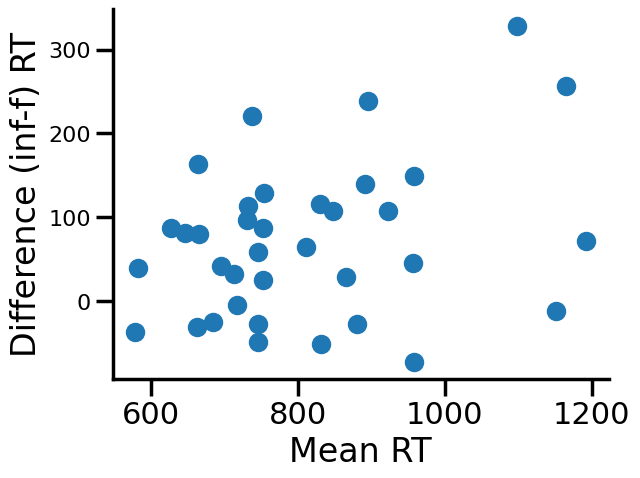

In [20]:
plt.scatter(x = train_mean_pivot['mean'], y = train_mean_pivot['diff'])
plt.xlabel('Mean RT')
plt.ylabel('Difference (inf-f) RT')
sns.despine();

In [21]:
pearson_r, p_value = stat.pearsonr(train_mean_pivot['mean'], train_mean_pivot['diff'])

print(f"Pearson correlation coefficient: {pearson_r}")
print(f"P-value: {p_value}")


Pearson correlation coefficient: 0.31573689392339965
P-value: 0.06067331518666198


In [22]:
colors = ["#1a80bb", '#a00000']

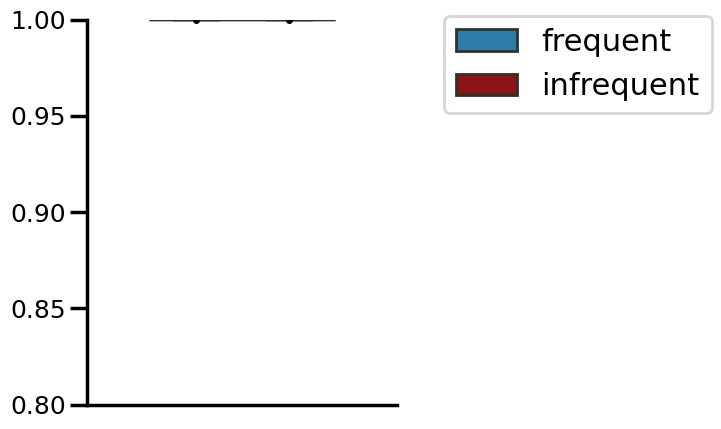

In [23]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 18})
ax = sns.boxplot(y="Accuracy", hue="TargetCondition", data=train_mean, width=0.6, legend=True, palette=colors, 
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
ax.set_ylim([0.8, 1])
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine()
# plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainAcc.png', bbox_inches = 'tight', dpi = 1080)

C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\1707608275.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="TargetCondition", y="RT", data=train_mean, width=0.6,


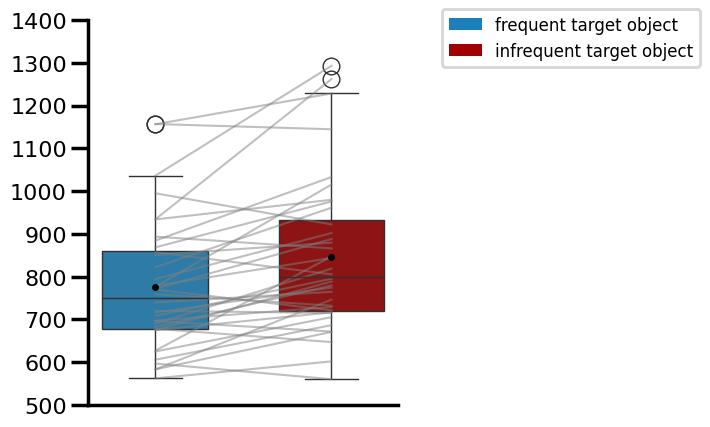

In [24]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 16})
ax = sns.boxplot(x="TargetCondition", y="RT", data=train_mean, width=0.6,
                 palette=colors, showmeans=True,
                 meanprops={"marker":"o","markerfacecolor":"black",
                            "markeredgecolor":"black","markersize":4})

for i, (pid, grp) in enumerate(train_mean.groupby('ID')):
    ax.plot(grp['TargetCondition'], grp['RT'], color = 'grey', alpha=0.5, lw=1.5)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
handles = [
    Patch(facecolor=colors[0], label='frequent target object'),
    Patch(facecolor=colors[1], label='infrequent target object')
]

plt.legend(handles=handles, bbox_to_anchor=(2, 1.05), fontsize=12)
ax.set_ylim([500, 1400])
ticks = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
ax.set_yticks(ticks);
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/trainRT.png', bbox_inches = 'tight', dpi = 1080)

In [25]:
# RT paired t-train
freq = train_mean[train_mean['TargetCondition'] == 'frequent']['RT']
infreq = train_mean[train_mean['TargetCondition'] == 'infrequent']['RT']
stat.ttest_rel(freq, infreq)

TtestResult(statistic=np.float64(-4.606355885410467), pvalue=np.float64(5.236443522933374e-05), df=np.int64(35))

In [26]:
diff = freq.values - infreq.values
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -0.768


In [27]:
train_valid_mean = train_mean[train_mean['ID'].isin(valid_group_ids)]
train_invalid_mean = train_mean[train_mean['ID'].isin(invalid_group_ids)]
train_learners_mean = train_mean[~train_mean['ID'].isin(no_learning_ids)]

C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\3324231091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(y="RT", x="TargetCondition", data=train_valid_mean, width=0.6, legend=True, palette=colors,


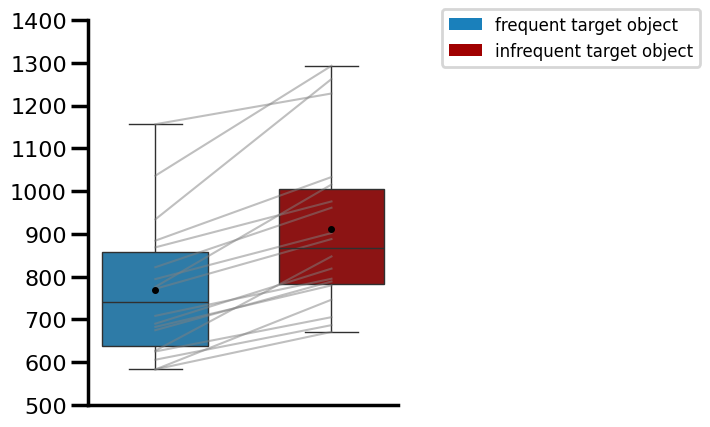

In [28]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 16})
ax = sns.boxplot(y="RT", x="TargetCondition", data=train_valid_mean, width=0.6, legend=True, palette=colors, 
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
for i, (pid, grp) in enumerate(train_valid_mean.groupby('ID')):
    ax.plot(grp['TargetCondition'], grp['RT'], color = 'grey', alpha=0.5, lw=1.5)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
handles = [
    Patch(facecolor=colors[0], label='frequent target object'),
    Patch(facecolor=colors[1], label='infrequent target object')
]
plt.legend(handles=handles, bbox_to_anchor=(2, 1.05), fontsize=12)
ax.set_ylim([500, 1400])
ticks = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
ax.set_yticks(ticks);
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/train_valid_RT.png', bbox_inches = 'tight', dpi = 1080)

In [29]:
# RT paired t-train
freq = train_valid_mean[train_valid_mean['TargetCondition'] == 'frequent']['RT']
infreq = train_valid_mean[train_valid_mean['TargetCondition'] == 'infrequent']['RT']
stat.ttest_rel(freq, infreq)

TtestResult(statistic=np.float64(-8.410708004282025), pvalue=np.float64(1.8339520052783188e-07), df=np.int64(17))

In [30]:
diff = freq.values - infreq.values
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -1.982


C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\3072216873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(y="RT", x="TargetCondition", data=train_invalid_mean, width=0.6, legend=True, palette=colors,


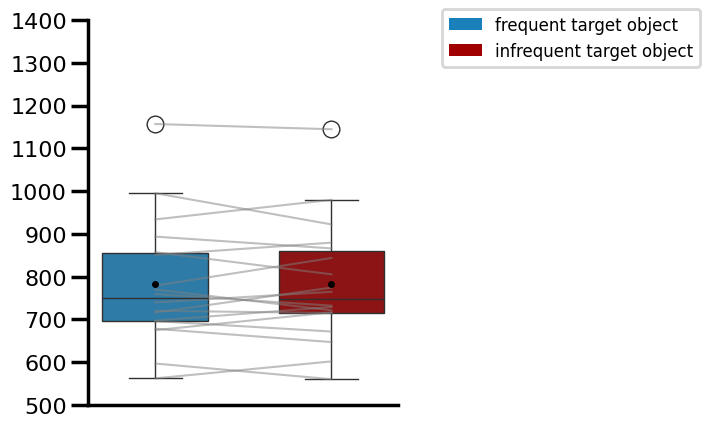

In [31]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 16})
ax = sns.boxplot(y="RT", x="TargetCondition", data=train_invalid_mean, width=0.6, legend=True, palette=colors, 
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
for i, (pid, grp) in enumerate(train_invalid_mean.groupby('ID')):
    ax.plot(grp['TargetCondition'], grp['RT'], color = 'grey', alpha=0.5, lw=1.5)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
handles = [
    Patch(facecolor=colors[0], label='frequent target object'),
    Patch(facecolor=colors[1], label='infrequent target object')
]
plt.legend(handles=handles, bbox_to_anchor=(2, 1.05), fontsize=12)
ax.set_ylim([500, 1400])
ticks = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
ax.set_yticks(ticks);
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/train_invalid_RT.png', bbox_inches = 'tight', dpi = 1080)

In [32]:
# RT paired t-train
freq = train_invalid_mean[train_invalid_mean['TargetCondition'] == 'frequent']['RT']
infreq = train_invalid_mean[train_invalid_mean['TargetCondition'] == 'infrequent']['RT']
stat.ttest_rel(freq, infreq)

TtestResult(statistic=np.float64(0.010620883018856412), pvalue=np.float64(0.991649566414244), df=np.int64(17))

In [33]:
diff = freq.values - infreq.values
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = 0.003


C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\796285149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(y="RT", x="TargetCondition", data=train_learners_mean, width=0.6, legend=True, palette=colors,


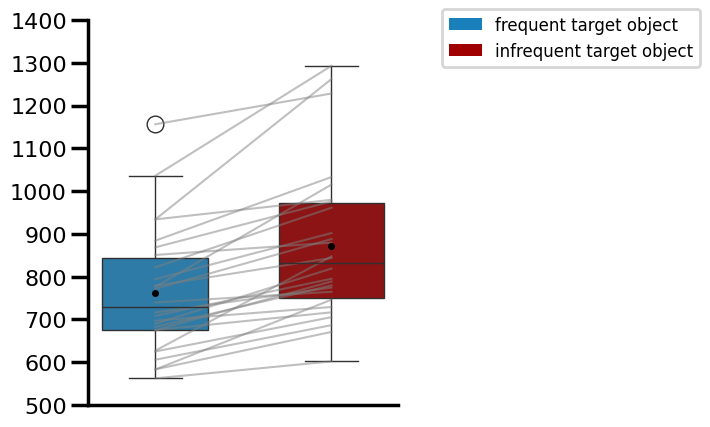

In [34]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 16})
ax = sns.boxplot(y="RT", x="TargetCondition", data=train_learners_mean, width=0.6, legend=True, palette=colors, 
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
for i, (pid, grp) in enumerate(train_learners_mean.groupby('ID')):
    ax.plot(grp['TargetCondition'], grp['RT'], color = 'grey', alpha=0.5, lw=1.5)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
handles = [
    Patch(facecolor=colors[0], label='frequent target object'),
    Patch(facecolor=colors[1], label='infrequent target object')
]
plt.legend(handles=handles, bbox_to_anchor=(2, 1.05), fontsize=12)
ax.set_ylim([500, 1400])
ticks = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
ax.set_yticks(ticks);
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/train_learners_RT.png', bbox_inches = 'tight', dpi = 1080)

In [35]:
# RT paired t-train
freq = train_learners_mean[train_learners_mean['TargetCondition'] == 'frequent']['RT']
infreq = train_learners_mean[train_learners_mean['TargetCondition'] == 'infrequent']['RT']
stat.ttest_rel(freq, infreq)

TtestResult(statistic=np.float64(-7.456348558062711), pvalue=np.float64(8.270706469279483e-08), df=np.int64(25))

In [36]:
diff = freq.values - infreq.values
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -1.462


#### block analysis

In [37]:
train = train.reset_index()
analysis_block = np.zeros(len(train))
for i in range(len(train)):
    if train['BlockNumber'][i] <= 4:
        analysis_block[i] = 1
    elif (train['BlockNumber'][i] > 4) & (train['BlockNumber'][i] <= 8):
        analysis_block[i] = 2
    else:
        analysis_block[i] = 3
train['AnalysisBlock'] = analysis_block

In [38]:
train_block_mean = train.groupby(['ID', 'BlockNumber', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
train_block_mean

,ID,BlockNumber,TargetCondition,RT,Accuracy
0,2,1,frequent,714.628993,1.0
1,2,1,infrequent,741.843925,1.0
2,2,2,frequent,595.988281,1.0
3,2,2,infrequent,634.483113,1.0
4,2,3,frequent,570.413079,1.0
...,...,...,...,...,...
853,49,10,infrequent,558.793393,1.0
854,49,11,frequent,524.873469,1.0
855,49,11,infrequent,508.145186,1.0
856,49,12,frequent,492.736800,1.0


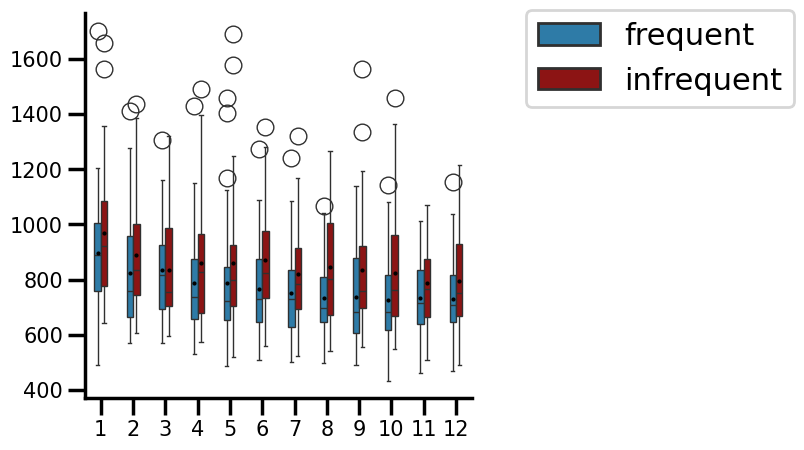

In [39]:
plt.figure(figsize=(5, 5))
sns.set_context("poster", rc={"xtick.labelsize": 15, "ytick.labelsize": 15})
ax = sns.boxplot(x="BlockNumber", y="RT", hue="TargetCondition", data=train_block_mean, width=0.4, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":2})
ax.set_xlabel("")
ax.set_ylabel("")
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainRTbyBlock.png', bbox_inches = 'tight', dpi = 1080)

In [40]:
# RT paired t-test
for block in range(1,13):
    t,p = stat.ttest_rel(train_block_mean[(train_block_mean['TargetCondition'] == 'frequent') & (train_block_mean['BlockNumber'] == (block))]['RT'], 
                   train_block_mean[(train_block_mean['TargetCondition'] == 'infrequent') & (train_block_mean['BlockNumber'] == (block))]['RT'])
    print(f"Block {block}: t = {t:.3f}, p = {p:.3f}")

Block 1: t = -2.191, p = 0.035
Block 2: t = -2.306, p = 0.027
Block 3: t = 0.069, p = 0.945
Block 4: t = -3.079, p = 0.004
Block 5: t = -2.441, p = 0.020
Block 6: t = -6.065, p = 0.000
Block 7: t = -3.095, p = 0.004
Block 8: t = -4.203, p = 0.000
Block 9: t = -4.021, p = 0.000
Block 10: t = -3.922, p = 0.000
Block 11: t = -2.726, p = 0.010
Block 12: t = -3.400, p = 0.002


In [41]:
train_valid = train[train['ID'].isin(valid_group_ids)]
train_invalid = train[train['ID'].isin(invalid_group_ids)]
train_block_mean_valid = train_valid.groupby(['ID', 'BlockNumber', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
train_block_mean_invalid = train_invalid.groupby(['ID', 'BlockNumber', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()

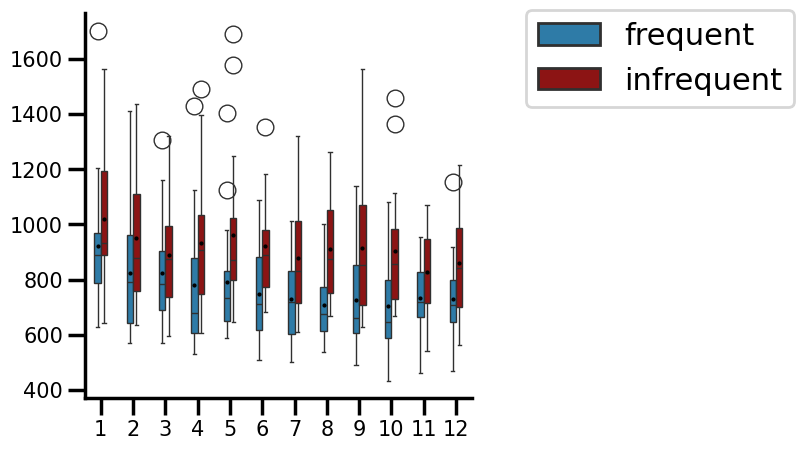

In [42]:
plt.figure(figsize=(5, 5))
sns.set_context("poster", rc={"xtick.labelsize": 15, "ytick.labelsize": 15})
ax = sns.boxplot(x="BlockNumber", y="RT", hue="TargetCondition", data=train_block_mean_valid, width=0.4, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":2})
ax.set_xlabel("")
ax.set_ylabel("")
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainRTbyBlockGood.png', bbox_inches = 'tight', dpi = 1080)

In [43]:
# RT paired t-test
for block in range(1,13):
    t,p = stat.ttest_rel(train_block_mean_valid[(train_block_mean_valid['TargetCondition'] == 'frequent') & (train_block_mean_valid['BlockNumber'] == (block))]['RT'], 
                   train_block_mean_valid[(train_block_mean_valid['TargetCondition'] == 'infrequent') & (train_block_mean_valid['BlockNumber'] == (block))]['RT'])
    print(f"Block {block}: t = {t:.3f}, p = {p:.3f}")

Block 1: t = -1.959, p = 0.068
Block 2: t = -3.600, p = 0.002
Block 3: t = -2.036, p = 0.058
Block 4: t = -6.135, p = 0.000
Block 5: t = -4.800, p = 0.000
Block 6: t = -10.877, p = 0.000
Block 7: t = -4.907, p = 0.000
Block 8: t = -5.947, p = 0.000
Block 9: t = -6.638, p = 0.000
Block 10: t = -7.110, p = 0.000
Block 11: t = -2.783, p = 0.013
Block 12: t = -5.877, p = 0.000


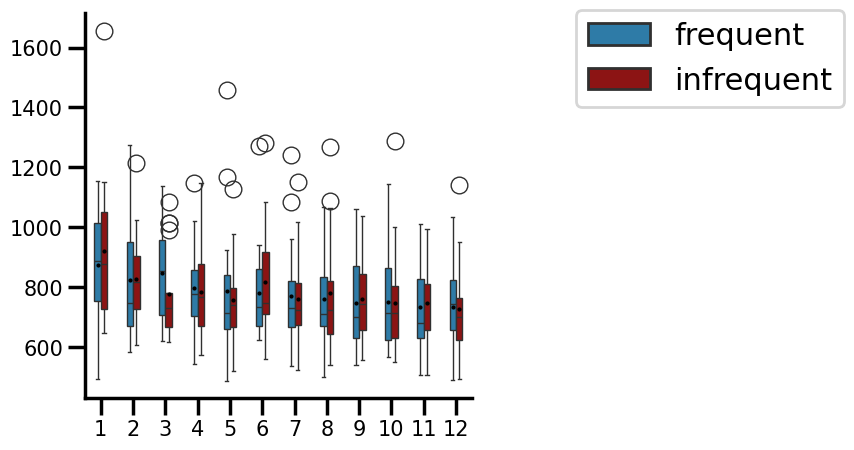

In [44]:
plt.figure(figsize=(5, 5))
sns.set_context("poster", rc={"xtick.labelsize": 15, "ytick.labelsize": 15})
ax = sns.boxplot(x="BlockNumber", y="RT", hue="TargetCondition", data=train_block_mean_invalid, width=0.4, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":2})
ax.set_xlabel("")
ax.set_ylabel("")
plt.legend(bbox_to_anchor=(2, 1.05))
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainRTbyBlockPoor.png', bbox_inches = 'tight', dpi = 1080)

In [45]:
# RT paired t-test
for block in range(1,13):
    t,p = stat.ttest_rel(train_block_mean_invalid[(train_block_mean_invalid['TargetCondition'] == 'frequent') & (train_block_mean_invalid['BlockNumber'] == (block))]['RT'], 
                   train_block_mean_invalid[(train_block_mean_invalid['TargetCondition'] == 'infrequent') & (train_block_mean_invalid['BlockNumber'] == (block))]['RT'])
    print(f"Block {block}: t = {t:.3f}, p = {p:.3f}")

Block 1: t = -1.083, p = 0.294
Block 2: t = -0.089, p = 0.930
Block 3: t = 2.681, p = 0.016
Block 4: t = 0.490, p = 0.630
Block 5: t = 1.056, p = 0.306
Block 6: t = -1.748, p = 0.099
Block 7: t = 0.529, p = 0.604
Block 8: t = -0.752, p = 0.463
Block 9: t = -0.464, p = 0.648
Block 10: t = 0.217, p = 0.831
Block 11: t = -0.834, p = 0.416
Block 12: t = 0.189, p = 0.852


#### priming

In [46]:
subs = np.unique(train['ID'])
train_prime = pd.DataFrame()
for sub in subs:
    train_sub = train[train['ID'] == sub].reset_index()
    for i in range(len(train_sub)-1):
        if train_sub['TargetID'][i+1] == train_sub['TargetID'][i]:
            train_prime = pd.concat([train_prime, train_sub.iloc[i+1:i+2]])
train_nonPrime = train[~train['index'].isin(train_prime['index'])]

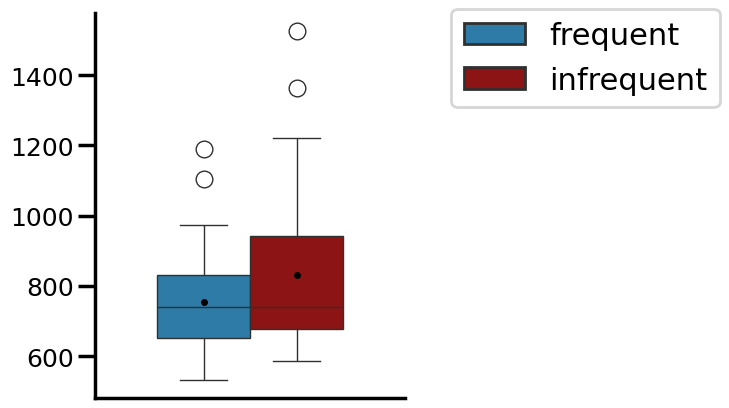

In [47]:
train_prime_mean = train_prime.groupby(['ID', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 18})
ax = sns.boxplot(y="RT", hue="TargetCondition", data=train_prime_mean, width=0.6, legend=True, palette=colors, 
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine()
# plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainRT.png', bbox_inches = 'tight', dpi = 1080)

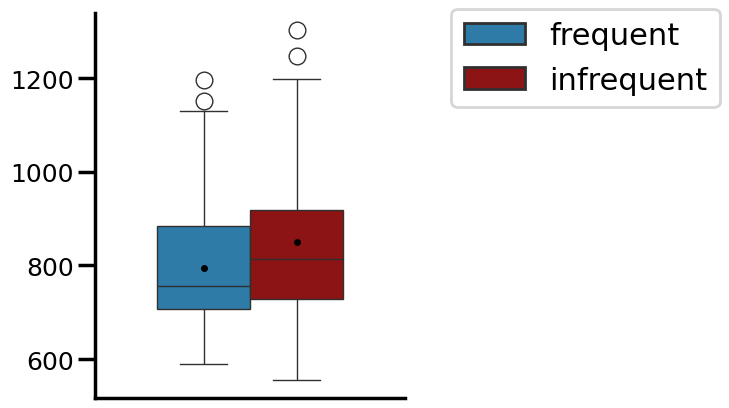

In [48]:
train_nonPrime_mean = train_nonPrime.groupby(['ID', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 18})
ax = sns.boxplot(y="RT", hue="TargetCondition", data=train_nonPrime_mean, width=0.6, legend=True, palette=colors, 
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine()
# plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainRT.png', bbox_inches = 'tight', dpi = 1080)

In [49]:
train_nonPrime_pivot = train_nonPrime_mean.pivot(index='ID', columns='TargetCondition', values='RT')
train_nonPrime_pivot['RT_diff'] = train_nonPrime_pivot['infrequent'] - train_nonPrime_pivot['frequent']
train_prime_pivot = train_prime_mean.pivot(index='ID', columns='TargetCondition', values='RT')
train_prime_pivot['RT_diff'] = train_prime_pivot['infrequent'] - train_prime_pivot['frequent']
rt_diff = pd.DataFrame({"prime": train_prime_pivot['RT_diff'], "nonPrime": train_nonPrime_pivot['RT_diff']})

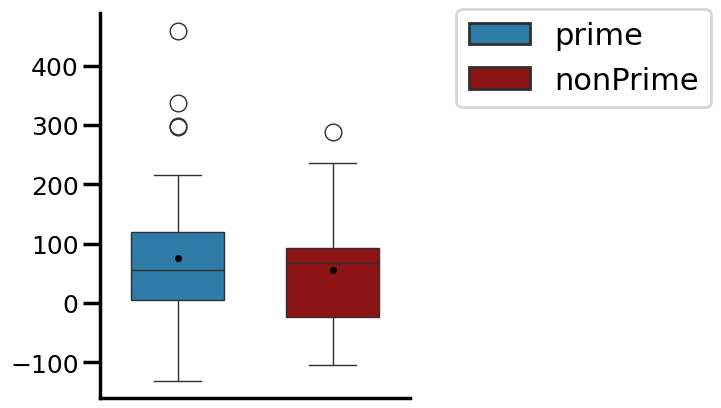

In [50]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 18})
ax = sns.boxplot(data=rt_diff, width=0.6, legend=True, palette=colors, 
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine()
# plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainPrime.png', bbox_inches = 'tight', dpi = 1080)

In [51]:
stat.ttest_rel(rt_diff['prime'], rt_diff['nonPrime'])

TtestResult(statistic=np.float64(1.2939601177965465), pvalue=np.float64(0.20415292933208715), df=np.int64(35))

In [52]:
subs = np.unique(train['ID'])
train_prime_loc = pd.DataFrame()
for sub in subs:
    train_sub = train[train['ID'] == sub].reset_index()
    for i in range(len(train_sub)-1):
        if train_sub['TargetLocation'][i+1] == train_sub['TargetLocation'][i]:
            train_prime_loc = pd.concat([train_prime_loc, train_sub.iloc[i+1:i+2]])
train_nonPrime_loc = train[~train['index'].isin(train_prime_loc['index'])]

train_prime_loc_mean = train_prime_loc.groupby(['ID', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
train_nonPrime_loc_mean = train_nonPrime_loc.groupby(['ID', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()

train_nonPrime_loc_pivot = train_nonPrime_loc_mean.pivot(index='ID', columns='TargetCondition', values='RT')
train_nonPrime_loc_pivot['RT_diff'] = train_nonPrime_loc_pivot['infrequent'] - train_nonPrime_loc_pivot['frequent']
train_prime_loc_pivot = train_prime_loc_mean.pivot(index='ID', columns='TargetCondition', values='RT')
train_prime_loc_pivot['RT_diff'] = train_prime_loc_pivot['infrequent'] - train_prime_loc_pivot['frequent']
rt_loc_diff = pd.DataFrame({"prime": train_prime_loc_pivot['RT_diff'], "nonPrime": train_nonPrime_pivot['RT_diff']})

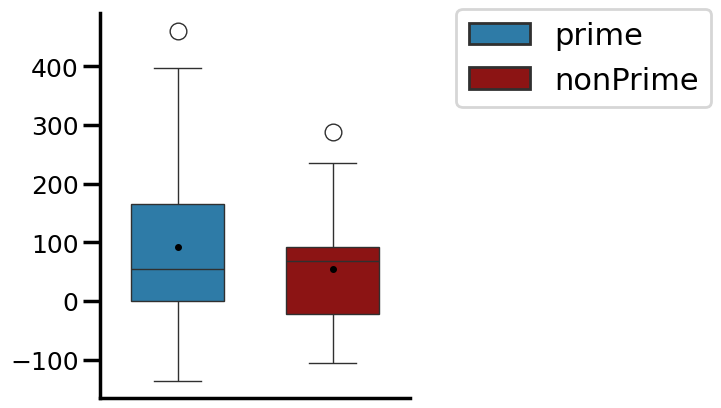

In [53]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 18})
ax = sns.boxplot(data=rt_loc_diff, width=0.6, legend=True, palette=colors, 
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine()
# plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainPrimeLoc.png', bbox_inches = 'tight', dpi = 1080)

In [54]:
stat.ttest_rel(rt_loc_diff['prime'], rt_loc_diff['nonPrime'])

TtestResult(statistic=np.float64(3.417203867308827), pvalue=np.float64(0.0016195680095975641), df=np.int64(35))

#### distribution

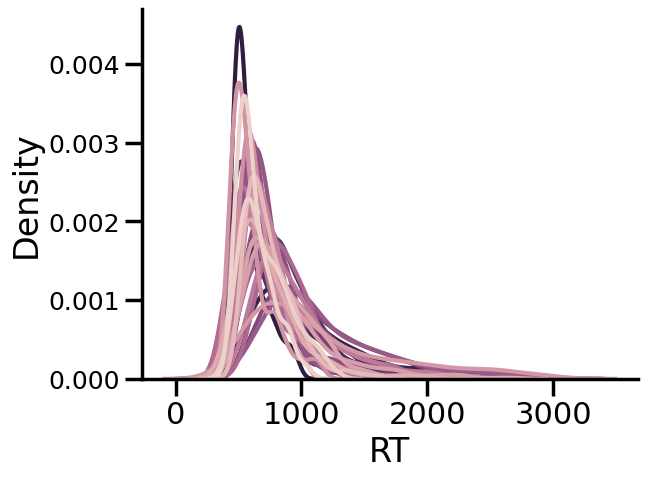

In [55]:
sns.kdeplot(data=train, x="RT", hue="ID", fill=False, common_norm=False, legend=False)
sns.despine();
# plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/trainRTDistribution.png', bbox_inches = 'tight', dpi = 1080)

### test

In [56]:
colors = ["#8cc5e3",'#d8a6a6']

In [57]:
test_mean = test.groupby(['ID', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
test.groupby('TargetCondition')[['RT', 'Accuracy']].mean()

,RT,Accuracy
TargetCondition,,
frequent,719.532816,1.0
infrequent,719.182273,1.0


In [58]:
test.groupby('TargetCondition')[['RT', 'Accuracy']].std()

,RT,Accuracy
TargetCondition,,
frequent,283.887184,0.0
infrequent,284.382054,0.0


In [59]:
test_mean_pivot = test_mean.pivot(index='ID', columns='TargetCondition', values='RT')
test_mean_pivot['diff'] = test_mean_pivot['infrequent'] - test_mean_pivot['frequent']
test_mean_pivot['mean'] = (test_mean_pivot['infrequent'] + test_mean_pivot['frequent'])/2

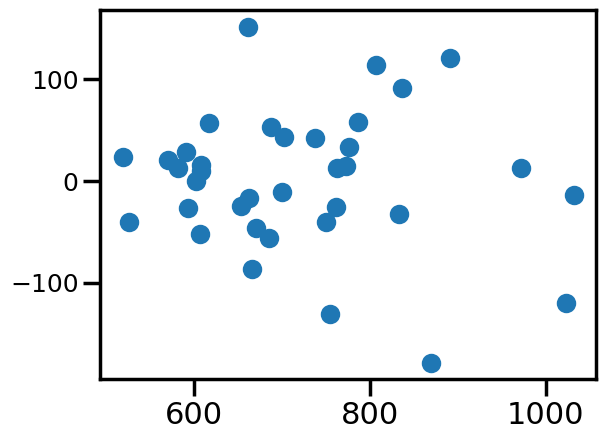

In [60]:
plt.scatter(x = test_mean_pivot['mean'], y = test_mean_pivot['diff'])

In [61]:
pearson_r, p_value = stat.pearsonr(test_mean_pivot['mean'], test_mean_pivot['diff'])

print(f"Pearson correlation coefficient: {pearson_r}")
print(f"P-value: {p_value}")

Pearson correlation coefficient: -0.09745050603069647
P-value: 0.5717905425019452


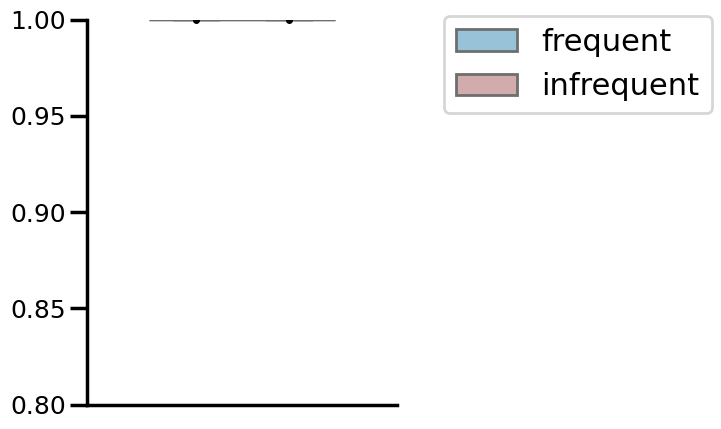

In [62]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 18})
ax = sns.boxplot(y="Accuracy", hue="TargetCondition", data=test_mean, width=0.6, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
ax.set_ylim([0.8, 1])
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine();
# plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/testAcc.png', bbox_inches = 'tight', dpi = 1080)

C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\1530140463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(y="RT", x="TargetCondition", data=test_mean, width=0.6, legend=True, palette=colors,


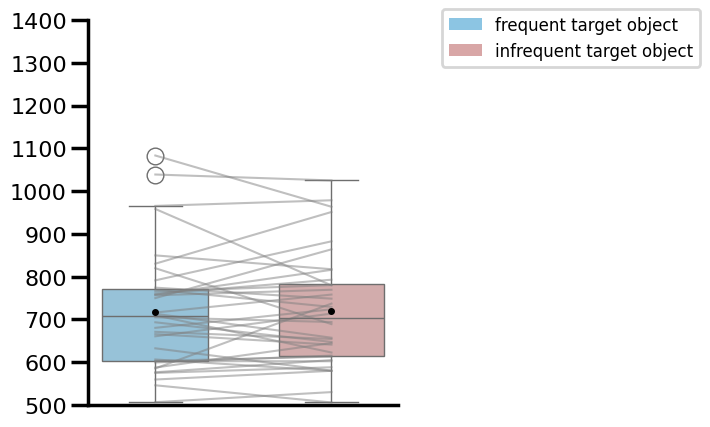

In [63]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 16})
ax = sns.boxplot(y="RT", x="TargetCondition", data=test_mean, width=0.6, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
for i, (pid, grp) in enumerate(test_mean.groupby('ID')):
    ax.plot(grp['TargetCondition'], grp['RT'], color = 'grey', alpha=0.5, lw=1.5)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
handles = [
    Patch(facecolor=colors[0], label='frequent target object'),
    Patch(facecolor=colors[1], label='infrequent target object')
]
ax.set_ylim([500, 1400])
plt.legend(handles=handles, bbox_to_anchor=(2, 1.05), fontsize=12)
ticks = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
ax.set_yticks(ticks);
sns.despine();
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/testRT.png', bbox_inches = 'tight', dpi = 1080)

In [64]:
# RT paired t-test
freq = test_mean[test_mean['TargetCondition'] == 'frequent']['RT']
infreq = test_mean[test_mean['TargetCondition'] == 'infrequent']['RT']
stat.ttest_rel(freq, infreq)

TtestResult(statistic=np.float64(-0.03900154308352229), pvalue=np.float64(0.969110780492515), df=np.int64(35))

In [65]:
diff = freq.values - infreq.values
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -0.007


In [66]:
test_valid_mean = test_mean[test_mean['ID'].isin(valid_group_ids)]
test_invalid_mean = test_mean[test_mean['ID'].isin(invalid_group_ids)]
test_learners_mean = test_mean[~test_mean['ID'].isin(no_learning_ids)]

C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\3910112532.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(y="RT", x="TargetCondition", data=test_valid_mean, width=0.6, legend=True, palette=colors,


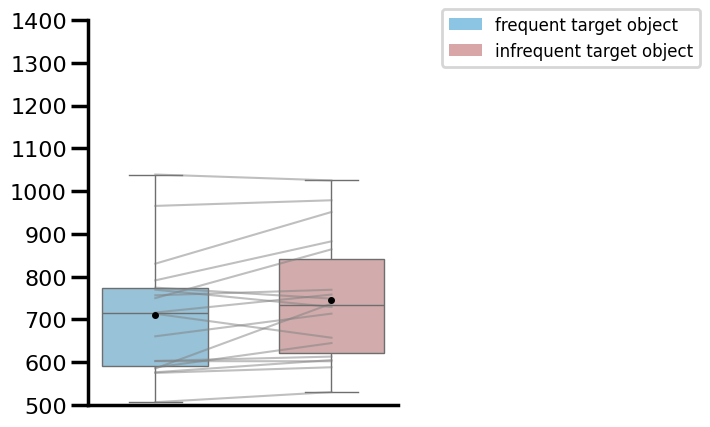

In [67]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 16})
ax = sns.boxplot(y="RT", x="TargetCondition", data=test_valid_mean, width=0.6, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
for i, (pid, grp) in enumerate(test_valid_mean.groupby('ID')):
    ax.plot(grp['TargetCondition'], grp['RT'], color = 'grey', alpha=0.5, lw=1.5)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
handles = [
    Patch(facecolor=colors[0], label='frequent target object'),
    Patch(facecolor=colors[1], label='infrequent target object')
]
ax.set_ylim([500, 1400])
plt.legend(handles=handles, bbox_to_anchor=(2, 1.05), fontsize=12)
ticks = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
ax.set_yticks(ticks);
sns.despine();
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/testRT_valid.png', bbox_inches = 'tight', dpi = 1080)

In [68]:
freq = test_valid_mean[test_valid_mean['TargetCondition'] == 'frequent']['RT']
infreq = test_valid_mean[test_valid_mean['TargetCondition'] == 'infrequent']['RT']
stat.ttest_rel(freq, infreq)

TtestResult(statistic=np.float64(-2.473881287171115), pvalue=np.float64(0.024206002219800373), df=np.int64(17))

In [69]:
diff = freq.values - infreq.values
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -0.583


C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\2342517924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(y="RT", x="TargetCondition", data=test_invalid_mean, width=0.6, legend=True, palette=colors,


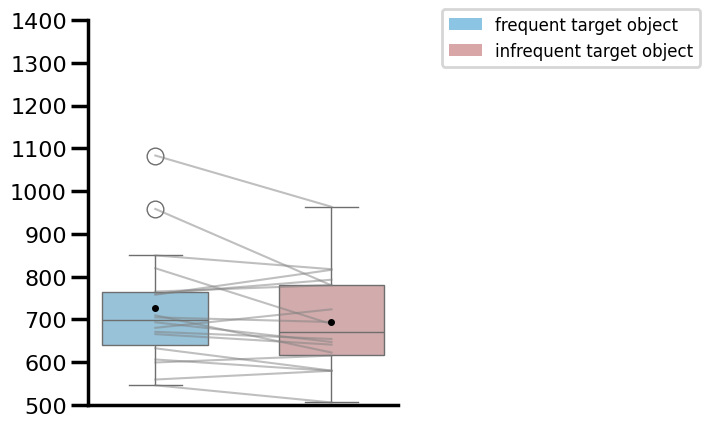

In [70]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 16})
ax = sns.boxplot(y="RT", x="TargetCondition", data=test_invalid_mean, width=0.6, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
for i, (pid, grp) in enumerate(test_invalid_mean.groupby('ID')):
    ax.plot(grp['TargetCondition'], grp['RT'], color = 'grey', alpha=0.5, lw=1.5)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
handles = [
    Patch(facecolor=colors[0], label='frequent target object'),
    Patch(facecolor=colors[1], label='infrequent target object')
]
ax.set_ylim([500, 1400])
plt.legend(handles=handles, bbox_to_anchor=(2, 1.05), fontsize=12)
ticks = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
ax.set_yticks(ticks);
sns.despine();
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/testRT_invalid.png', bbox_inches = 'tight', dpi = 1080)

In [71]:
freq = test_invalid_mean[test_invalid_mean['TargetCondition'] == 'frequent']['RT']
infreq = test_invalid_mean[test_invalid_mean['TargetCondition'] == 'infrequent']['RT']
stat.ttest_rel(freq, infreq)

TtestResult(statistic=np.float64(2.1481561253239128), pvalue=np.float64(0.04640695829113653), df=np.int64(17))

In [72]:
diff = freq.values - infreq.values
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = 0.506


C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\3043798902.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(y="RT", x="TargetCondition", data=test_learners_mean, width=0.6, legend=True, palette=colors,


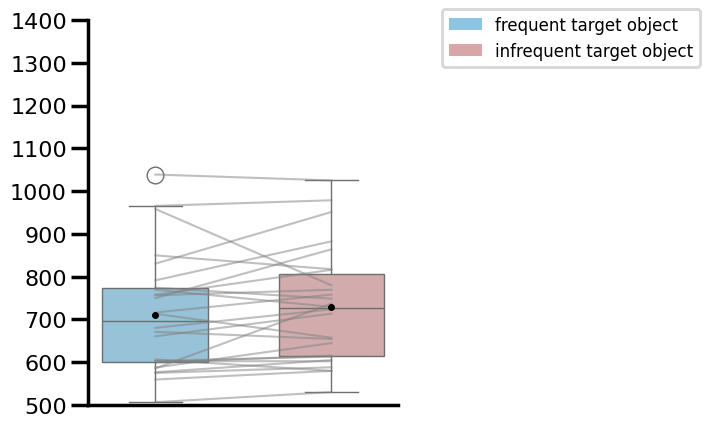

In [73]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 16})
ax = sns.boxplot(y="RT", x="TargetCondition", data=test_learners_mean, width=0.6, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
for i, (pid, grp) in enumerate(test_learners_mean.groupby('ID')):
    ax.plot(grp['TargetCondition'], grp['RT'], color = 'grey', alpha=0.5, lw=1.5)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
handles = [
    Patch(facecolor=colors[0], label='frequent target object'),
    Patch(facecolor=colors[1], label='infrequent target object')
]
ax.set_ylim([500, 1400])
plt.legend(handles=handles, bbox_to_anchor=(2, 1.05), fontsize=12)
ticks = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
ax.set_yticks(ticks);
sns.despine();
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/testRT_learners.png', bbox_inches = 'tight', dpi = 1080)

In [74]:
freq = test_learners_mean[test_learners_mean['TargetCondition'] == 'frequent']['RT']
infreq = test_learners_mean[test_learners_mean['TargetCondition'] == 'infrequent']['RT']
stat.ttest_rel(freq, infreq)

TtestResult(statistic=np.float64(-1.4461568747994313), pvalue=np.float64(0.16055476103617206), df=np.int64(25))

In [75]:
diff = freq.values - infreq.values
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -0.284


#### block analysis

In [76]:
test = test.reset_index()
analysis_block = np.zeros(len(test))
for i in range(len(test)):
    if (test['BlockNumber'][i] > 12) & (test['BlockNumber'][i] <= 24):
        analysis_block[i] = 1
    else:
        analysis_block[i] = 2
test['AnalysisBlock'] = analysis_block

In [77]:
test_block_mean = test.groupby(['ID', 'BlockNumber', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()

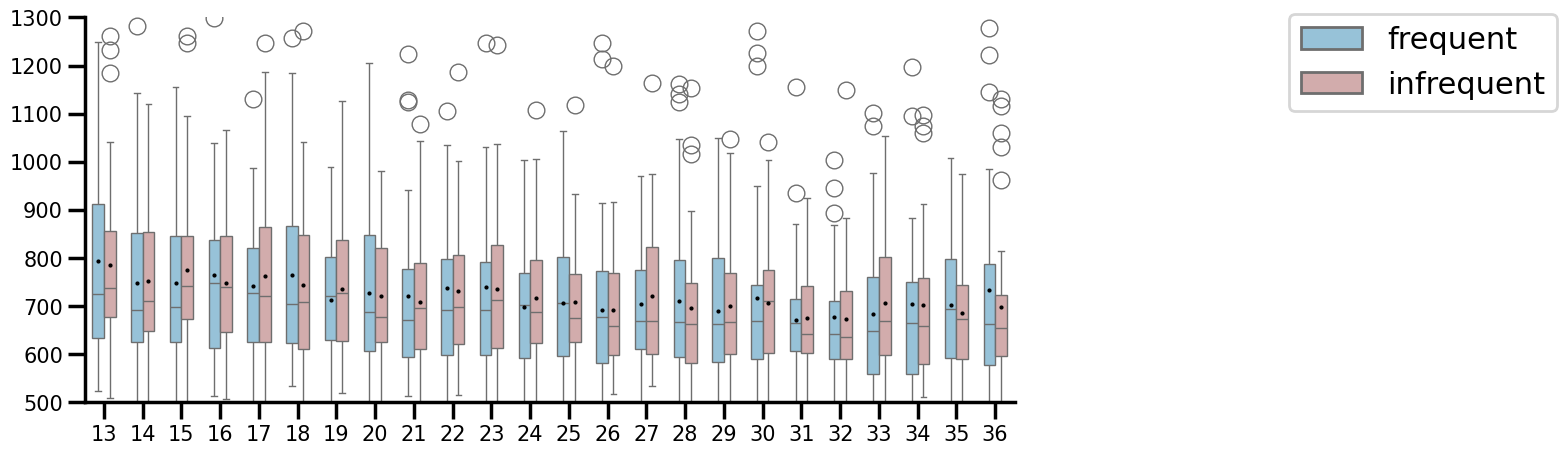

In [78]:
plt.figure(figsize=(12, 5))
sns.set_context("poster", rc={"xtick.labelsize": 15, "ytick.labelsize": 15})
ax = sns.boxplot(x="BlockNumber", y="RT", hue="TargetCondition", data=test_block_mean, width=0.6, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":2})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_ylim([500, 1300])
plt.legend(bbox_to_anchor=(1.6, 1.05))
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/testRTbyBlock.png', bbox_inches = 'tight', dpi = 1080)

In [79]:
for block in range(13, 37):
    freq = test_block_mean[(test_block_mean['TargetCondition'] == 'frequent') & 
                                  (test_block_mean['BlockNumber'] == block)].set_index('ID')
    infreq = test_block_mean[(test_block_mean['TargetCondition'] == 'infrequent') & 
                                    (test_block_mean['BlockNumber'] == block)].set_index('ID')

    common_ids = freq.index.intersection(infreq.index)
    
    if len(common_ids) < 2:
        print(f"Block {block}: not enough paired data, skipping")
        continue

    t, p = stat.ttest_rel(freq.loc[common_ids, 'RT'], infreq.loc[common_ids, 'RT'])
    print(f"Block {block}: t = {t:.4f}, p = {p:.4f}, n = {len(common_ids)}")

Block 13: t = 0.4268, p = 0.6722, n = 36
Block 14: t = -0.2109, p = 0.8342, n = 35
Block 15: t = -1.4150, p = 0.1659, n = 36
Block 16: t = 0.7547, p = 0.4555, n = 36
Block 17: t = -0.8303, p = 0.4120, n = 36
Block 18: t = 0.5858, p = 0.5619, n = 35
Block 19: t = -1.4958, p = 0.1437, n = 36
Block 20: t = 0.3051, p = 0.7621, n = 36
Block 21: t = 0.6034, p = 0.5501, n = 36
Block 22: t = 0.2049, p = 0.8388, n = 36
Block 23: t = 0.1819, p = 0.8567, n = 36
Block 24: t = -1.4129, p = 0.1665, n = 36
Block 25: t = -0.1187, p = 0.9062, n = 36
Block 26: t = 0.0009, p = 0.9993, n = 35
Block 27: t = -0.6846, p = 0.4981, n = 36
Block 28: t = 0.9440, p = 0.3516, n = 36
Block 29: t = -0.5664, p = 0.5747, n = 36
Block 30: t = 0.3655, p = 0.7169, n = 36
Block 31: t = 0.1401, p = 0.8894, n = 35
Block 32: t = 0.2354, p = 0.8153, n = 35
Block 33: t = -1.4149, p = 0.1662, n = 35
Block 34: t = 0.0934, p = 0.9261, n = 36
Block 35: t = 0.8910, p = 0.3790, n = 36
Block 36: t = 1.3345, p = 0.1912, n = 34


In [80]:
test_valid = test[test['ID'].isin(valid_group_ids)]
test_invalid = test[test['ID'].isin(invalid_group_ids)]
test_block_mean_valid = test_valid.groupby(['ID', 'BlockNumber', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()
test_block_mean_invalid = test_invalid.groupby(['ID', 'BlockNumber', 'TargetCondition'])[['RT', 'Accuracy']].mean().reset_index()

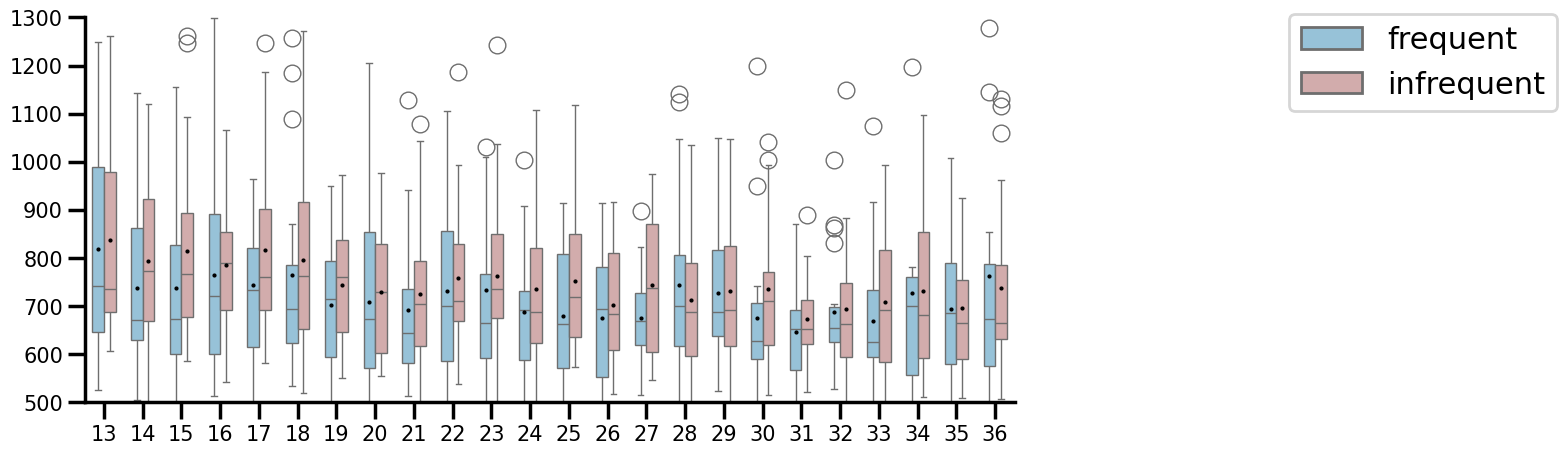

In [81]:
plt.figure(figsize=(12, 5))
sns.set_context("poster", rc={"xtick.labelsize": 15, "ytick.labelsize": 15})
ax = sns.boxplot(x="BlockNumber", y="RT", hue="TargetCondition", data=test_block_mean_valid, width=0.6, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":2})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_ylim([500, 1300])
plt.legend(bbox_to_anchor=(1.6, 1.05))
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/testRTbyBlockGood.png', bbox_inches = 'tight', dpi = 1080)

In [82]:
for block in range(13, 37):
    freq = test_block_mean_valid[(test_block_mean_valid['TargetCondition'] == 'frequent') & 
                                  (test_block_mean_valid['BlockNumber'] == block)].set_index('ID')
    infreq = test_block_mean_valid[(test_block_mean_valid['TargetCondition'] == 'infrequent') & 
                                    (test_block_mean_valid['BlockNumber'] == block)].set_index('ID')

    common_ids = freq.index.intersection(infreq.index)
    
    if len(common_ids) < 2:
        print(f"Block {block}: not enough paired data, skipping")
        continue

    t, p = stat.ttest_rel(freq.loc[common_ids, 'RT'], infreq.loc[common_ids, 'RT'])
    print(f"Block {block}: t = {t:.4f}, p = {p:.4f}, n = {len(common_ids)}")

Block 13: t = -0.5390, p = 0.5969, n = 18
Block 14: t = -1.9457, p = 0.0695, n = 17
Block 15: t = -3.6589, p = 0.0019, n = 18
Block 16: t = -0.6301, p = 0.5370, n = 18
Block 17: t = -2.1695, p = 0.0445, n = 18
Block 18: t = -0.5188, p = 0.6110, n = 17
Block 19: t = -2.0524, p = 0.0559, n = 18
Block 20: t = -0.6904, p = 0.4993, n = 18
Block 21: t = -1.4367, p = 0.1690, n = 18
Block 22: t = -0.7907, p = 0.4400, n = 18
Block 23: t = -0.8565, p = 0.4037, n = 18
Block 24: t = -2.4050, p = 0.0278, n = 18
Block 25: t = -1.9860, p = 0.0634, n = 18
Block 26: t = -1.8858, p = 0.0765, n = 18
Block 27: t = -2.3858, p = 0.0289, n = 18
Block 28: t = 1.2877, p = 0.2151, n = 18
Block 29: t = -0.1160, p = 0.9090, n = 18
Block 30: t = -2.0276, p = 0.0586, n = 18
Block 31: t = -1.7083, p = 0.1058, n = 18
Block 32: t = -0.1628, p = 0.8726, n = 18
Block 33: t = -2.4577, p = 0.0250, n = 18
Block 34: t = -0.0898, p = 0.9295, n = 18
Block 35: t = -0.0656, p = 0.9484, n = 18
Block 36: t = 0.7766, p = 0.4487, n

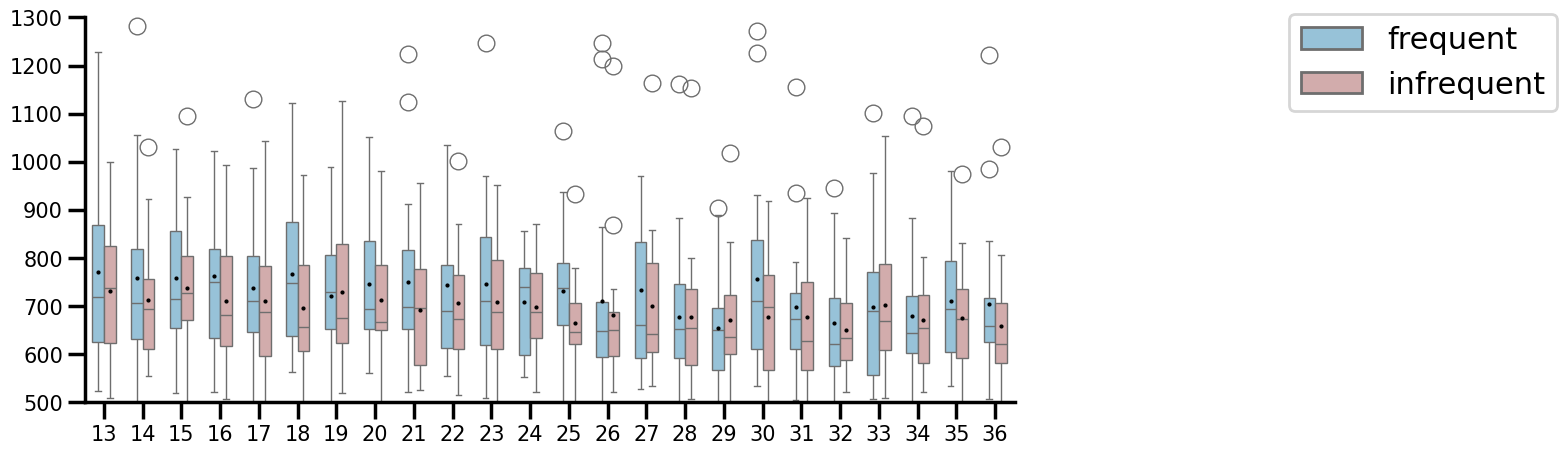

In [83]:
plt.figure(figsize=(12, 5))
sns.set_context("poster", rc={"xtick.labelsize": 15, "ytick.labelsize": 15})
ax = sns.boxplot(x="BlockNumber", y="RT", hue="TargetCondition", data=test_block_mean_invalid, width=0.6, legend=True, palette=colors,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":2})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_ylim([500, 1300])
plt.legend(bbox_to_anchor=(1.6, 1.05))
sns.despine()
plt.savefig('C:/Experiments/object_learning_EEG/ERP_analysis/behavior_figures/testRTbyBlockPoor.png', bbox_inches = 'tight', dpi = 1080)

In [84]:
for block in range(13, 37):
    freq = test_block_mean_invalid[(test_block_mean_invalid['TargetCondition'] == 'frequent') & 
                                  (test_block_mean_invalid['BlockNumber'] == block)].set_index('ID')
    infreq = test_block_mean_invalid[(test_block_mean_invalid['TargetCondition'] == 'infrequent') & 
                                    (test_block_mean_invalid['BlockNumber'] == block)].set_index('ID')

    common_ids = freq.index.intersection(infreq.index)
    
    if len(common_ids) < 2:
        print(f"Block {block}: not enough paired data, skipping")
        continue

    t, p = stat.ttest_rel(freq.loc[common_ids, 'RT'], infreq.loc[common_ids, 'RT'])
    print(f"Block {block}: t = {t:.4f}, p = {p:.4f}, n = {len(common_ids)}")

Block 13: t = 1.2389, p = 0.2322, n = 18
Block 14: t = 2.3520, p = 0.0310, n = 18
Block 15: t = 0.7248, p = 0.4784, n = 18
Block 16: t = 1.6667, p = 0.1139, n = 18
Block 17: t = 0.7310, p = 0.4747, n = 18
Block 18: t = 2.2537, p = 0.0377, n = 18
Block 19: t = -0.3138, p = 0.7575, n = 18
Block 20: t = 1.1449, p = 0.2681, n = 18
Block 21: t = 1.9765, p = 0.0646, n = 18
Block 22: t = 0.9290, p = 0.3659, n = 18
Block 23: t = 1.0581, p = 0.3048, n = 18
Block 24: t = 0.5663, p = 0.5786, n = 18
Block 25: t = 3.3287, p = 0.0040, n = 18
Block 26: t = 0.7130, p = 0.4861, n = 17
Block 27: t = 0.8226, p = 0.4222, n = 18
Block 28: t = 0.0379, p = 0.9702, n = 18
Block 29: t = -0.7474, p = 0.4651, n = 18
Block 30: t = 1.9310, p = 0.0703, n = 18
Block 31: t = 1.3202, p = 0.2053, n = 17
Block 32: t = 0.6732, p = 0.5104, n = 17
Block 33: t = -0.1432, p = 0.8880, n = 17
Block 34: t = 0.4855, p = 0.6335, n = 18
Block 35: t = 1.1634, p = 0.2607, n = 18
Block 36: t = 1.3426, p = 0.1982, n = 17


#### distribution

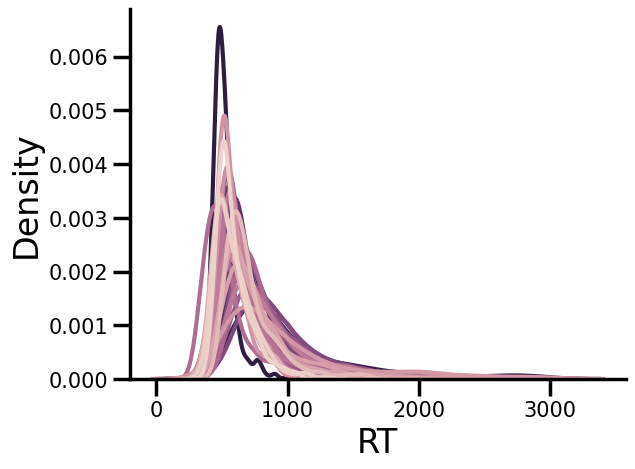

In [85]:
sns.kdeplot(data=test, x="RT", hue="ID", fill=False, common_norm=False, legend=False)
sns.despine();
plt.savefig('C:/Experiments/object_learning_EEG/behavior_figures/testRTDistribution.png', bbox_inches = 'tight', dpi = 1080)

### Standardized RT

In [86]:
combined_rt = pd.concat([train, test])
combined_rt['rt_z'] = combined_rt.groupby(['ID'])['RT'].transform(
    lambda x: (x - x.mean()) / x.std()
)
combined_rt['phase'] = np.where(combined_rt['BlockNumber'] < 13, 1, 2)

In [87]:
rt_standardize_summary = combined_rt.groupby(['ID', 'phase', 'TargetCondition'])['rt_z'].mean().reset_index()
rt_standardize_summary

,ID,phase,TargetCondition,rt_z
0,2,1,frequent,-0.111481
1,2,1,infrequent,0.540162
2,2,2,frequent,-0.173351
3,2,2,infrequent,-0.075150
4,3,1,frequent,0.476069
...,...,...,...,...
139,48,2,infrequent,-0.079450
140,49,1,frequent,0.613118
141,49,1,infrequent,0.256076
142,49,2,frequent,0.117996


In [88]:
rt_summary = combined_rt.groupby(['ID', 'phase', 'TargetCondition'])['RT'].mean().reset_index()

In [89]:
rt_aov = pg.rm_anova(
    data = rt_summary,
    dv = 'RT',
    within = ['phase', 'TargetCondition'],
    subject = 'ID'
)
print(rt_aov)

                    Source             SS  ddof1  ddof2             MS  \
0                    phase  304909.812137      1     35  304909.812137   
1          TargetCondition   46493.948763      1     35   46493.948763   
2  phase * TargetCondition   45357.711381      1     35   45357.711381   

           F         p-unc     p-GG-corr       ng2  eps  
0  72.945891  4.431198e-10  4.431198e-10  0.087226  1.0  
1   9.623395  3.785931e-03  3.785931e-03  0.014362  1.0  
2  25.094103  1.559364e-05  1.559364e-05  0.014016  1.0  


c:\Users\dartuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\dartuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [90]:
rt_standarized_aov = pg.rm_anova(
    data = rt_standardize_summary,
    dv = 'rt_z',
    within = ['phase', 'TargetCondition'],
    subject = 'ID'
)
print(rt_standarized_aov)

                    Source        SS  ddof1  ddof2        MS           F  \
0                    phase  4.896706      1     35  4.896706  109.701722   
1          TargetCondition  0.696158      1     35  0.696158    9.281907   
2  phase * TargetCondition  0.686610      1     35  0.686610   38.352913   

          p-unc     p-GG-corr       ng2  eps  
0  2.489795e-12  2.489795e-12  0.483727  1.0  
1  4.381521e-03  4.381521e-03  0.117548  1.0  
2  4.303782e-07  4.303782e-07  0.116123  1.0  


c:\Users\dartuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\dartuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


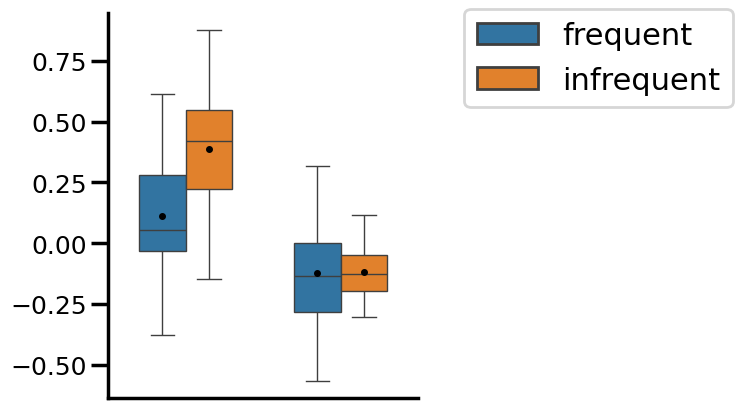

In [91]:
plt.figure(figsize=(4, 5))
sns.set_context("poster", rc={"ytick.labelsize": 18})
ax = sns.boxplot(x = "phase", y="rt_z", hue="TargetCondition", data=rt_standardize_summary, width=0.6, legend=True,
                 showmeans=True, meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black","markersize":4})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set(xticks=[])
plt.legend(bbox_to_anchor=(1.1, 1.05))
sns.despine();

In [92]:
stat.ttest_rel(rt_standardize_summary[(rt_standardize_summary['phase'] == 1) & (rt_standardize_summary['TargetCondition'] == 'frequent')]['rt_z'], 
               rt_standardize_summary[(rt_standardize_summary['phase'] == 1) & (rt_standardize_summary['TargetCondition'] == 'infrequent')]['rt_z'])

TtestResult(statistic=np.float64(-4.859015814140974), pvalue=np.float64(2.454283526300859e-05), df=np.int64(35))

In [93]:
stat.ttest_rel(rt_standardize_summary[(rt_standardize_summary['phase'] == 2) & (rt_standardize_summary['TargetCondition'] == 'frequent')]['rt_z'], 
               rt_standardize_summary[(rt_standardize_summary['phase'] == 2) & (rt_standardize_summary['TargetCondition'] == 'infrequent')]['rt_z'])

TtestResult(statistic=np.float64(-0.0219101496585732), pvalue=np.float64(0.9826440662078568), df=np.int64(35))

### RT Consistency

In [94]:
train_rt_std = train.groupby(['ID', 'TargetCondition'])['RT'].std().reset_index()
test_rt_std = test.groupby(['ID', 'TargetCondition'])['RT'].std().reset_index()

In [95]:
train_rt_std['phase'] = np.ones(len(train_rt_std))
test_rt_std['phase'] = np.ones(len(test_rt_std)) * 2

In [96]:
rt_std = pd.concat([train_rt_std, test_rt_std])

In [97]:
rt_consistency_aov = pg.rm_anova(
    data = rt_std,
    dv = 'RT',
    within = ['phase', 'TargetCondition'],
    subject = 'ID'
)
print(rt_consistency_aov)

                    Source            SS  ddof1  ddof2            MS  \
0                    phase  40231.651631      1     35  40231.651631   
1          TargetCondition  10373.371404      1     35  10373.371404   
2  phase * TargetCondition   4467.789902      1     35   4467.789902   

           F     p-unc  p-GG-corr       ng2  eps  
0  27.791928  0.000007   0.000007  0.024287  1.0  
1   6.511981  0.015238   0.015238  0.006377  1.0  
2   3.482216  0.070430   0.070430  0.002757  1.0  


c:\Users\dartuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\dartuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [98]:
rt_std

,ID,TargetCondition,RT,phase
0,2,frequent,122.971727,1.0
1,2,infrequent,140.834242,1.0
2,3,frequent,197.944000,1.0
3,3,infrequent,194.613215,1.0
4,7,frequent,189.258387,1.0
...,...,...,...,...
67,47,infrequent,508.036899,2.0
68,48,frequent,228.945213,2.0
69,48,infrequent,270.376381,2.0
70,49,frequent,98.602451,2.0


In [99]:
train_rt_std[train_rt_std['TargetCondition'] == 'frequent']['RT'].mean()

np.float64(253.18137113972352)

In [100]:
train_rt_std[train_rt_std['TargetCondition'] == 'infrequent']['RT'].mean()

np.float64(281.29658404512395)

In [101]:
test_rt_std['RT'].mean()

np.float64(233.80926208914448)

In [102]:
test_rt_std[test_rt_std['TargetCondition'] == 'frequent']['RT'].mean()

np.float64(230.8919103482837)

In [103]:
test_rt_std[test_rt_std['TargetCondition'] == 'infrequent']['RT'].mean()

np.float64(236.72661383000533)

In [104]:
stat.ttest_rel(train_rt_std['RT'], test_rt_std['RT'])

TtestResult(statistic=np.float64(5.343507302196653), pvalue=np.float64(1.0494956025688138e-06), df=np.int64(71))

In [105]:
stat.ttest_rel(train_rt_std[train_rt_std['TargetCondition'] == 'frequent']['RT'], train_rt_std[train_rt_std['TargetCondition'] == 'infrequent']['RT'])

TtestResult(statistic=np.float64(-3.0133020867540714), pvalue=np.float64(0.0047802713383357535), df=np.int64(35))

In [106]:
stat.ttest_rel(test_rt_std[test_rt_std['TargetCondition'] == 'frequent']['RT'], test_rt_std[test_rt_std['TargetCondition'] == 'infrequent']['RT'])

TtestResult(statistic=np.float64(-0.6842048257342319), pvalue=np.float64(0.49835146849707557), df=np.int64(35))

# Correlations

## learning and testing RT difference

In [107]:
train_copy = train.copy()
test_copy  = test.copy()

train_copy['Phase'] = 'learning'
test_copy['Phase']  = 'testing'
 
df = pd.concat([train_copy, test_copy], ignore_index=True)
df['LearnerGroup'] = df['ID'].apply(
    lambda x: 'good' if x in valid_group_ids else 'poor'
)

rt_diff = (df
           .groupby(['ID', 'Phase', 'TargetCondition'])['RT']
           .mean()
           .reset_index())

# Pivot to wide format then compute difference
rt_diff_wide = rt_diff.pivot_table(index=['ID', 'Phase'], 
                                    columns='TargetCondition', 
                                    values='RT').reset_index()
rt_diff_wide.columns.name = None
rt_diff_wide['RT_diff'] = rt_diff_wide['infrequent'] - rt_diff_wide['frequent']
rt_diff_phases = rt_diff_wide.pivot_table(
    index='ID', 
    columns='Phase', 
    values='RT_diff'
).reset_index()
rt_diff_phases.columns.name = None

In [108]:
rt_diff_phases.mean(), rt_diff_phases.std()

(ID          28.138889
 learning    71.433009
 testing      0.441843
 dtype: float64,
 ID          13.497413
 learning    93.044929
 testing     67.973102
 dtype: float64)

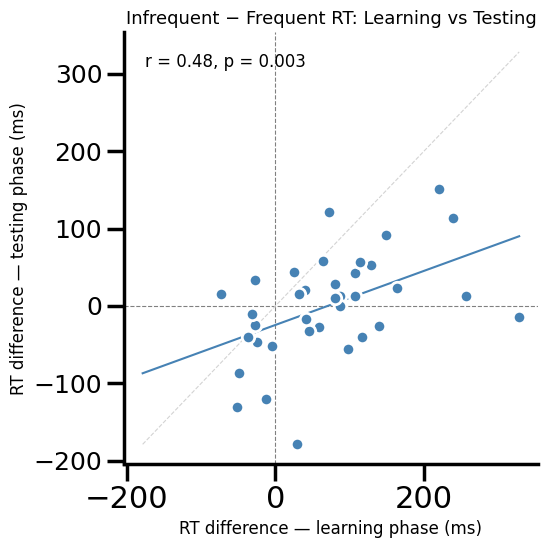

Pearson r = 0.478, p = 0.0032


In [109]:
# Correlation
r, p = stat.pearsonr(rt_diff_phases['learning'], rt_diff_phases['testing'])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(rt_diff_phases['learning'], rt_diff_phases['testing'], 
           color='steelblue', edgecolors='white', s=80, zorder=3)

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Identity line (learning = testing)
lims = [min(rt_diff_phases[['learning', 'testing']].min()),
        max(rt_diff_phases[['learning', 'testing']].max())]
ax.plot(lims, lims, color='lightgray', linestyle='--', linewidth=0.8, label='identity')

# Regression line
m, b = np.polyfit(rt_diff_phases['learning'], rt_diff_phases['testing'], 1)
x_line = np.linspace(lims[0], lims[1], 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5)

# Annotate correlation
ax.text(0.05, 0.92, f'r = {r:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=12)

ax.set_xlabel('RT difference — learning phase (ms)', fontsize=12)
ax.set_ylabel('RT difference — testing phase (ms)', fontsize=12)
ax.set_title('Infrequent − Frequent RT: Learning vs Testing', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.4f}")

## RT and latency differences

In [110]:
os.chdir('../')
ind_latency = pd.read_csv('individual_N2pc_latencies.csv')

In [111]:
ind_latency_wide = ind_latency.pivot_table(index='subject', columns=['phase', 'frequency'], values='latency')

# Infrequent - Frequent
ind_latency_diff = pd.DataFrame({
    'subject':         ind_latency_wide.index,
    'learning':      ind_latency_wide[('Train', 'Infrequent')] - ind_latency_wide[('Train', 'Frequent')],
    'testing':       ind_latency_wide[('Test',  'Infrequent')] - ind_latency_wide[('Test',  'Frequent')],
}).reset_index(drop=True)

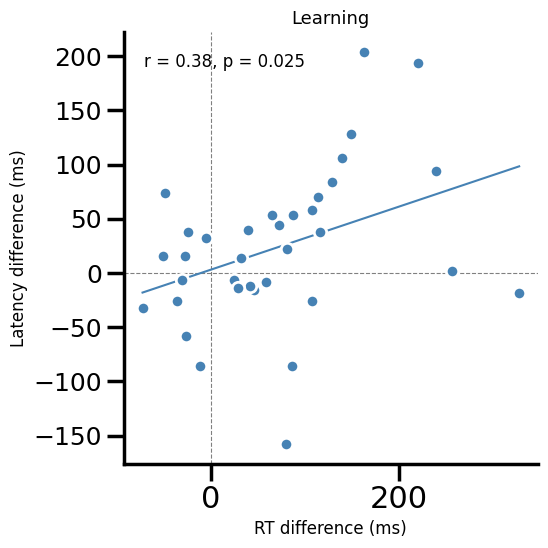

Pearson r = 0.379, p = 0.0249


In [112]:
# Correlation
x = np.asarray(rt_diff_phases['learning'], dtype=float)
y = np.asarray(ind_latency_diff['learning'], dtype=float)
mask = ~np.isnan(x) & ~np.isnan(y)   # rows where BOTH are present
r, p = stat.pearsonr(x[mask], y[mask])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x[mask], y[mask], 
           color='steelblue', edgecolors='white', s=80, zorder=3)

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Regression line
m, b = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5)

# Annotate correlation
ax.text(0.05, 0.92, f'r = {r:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=12)

ax.set_xlabel('RT difference (ms)', fontsize=12)
ax.set_ylabel('Latency difference (ms)', fontsize=12)
ax.set_title('Learning', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.4f}")

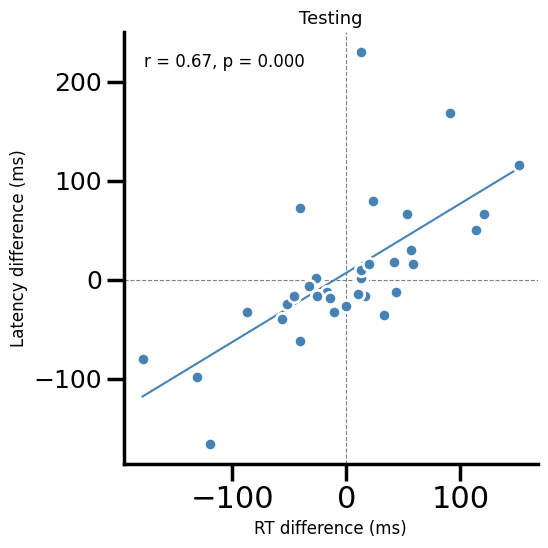

Pearson r = 0.673, p = 0.0000


In [113]:
# Correlation
x = np.asarray(rt_diff_phases['testing'], dtype=float)
y = np.asarray(ind_latency_diff['testing'], dtype=float)
mask = ~np.isnan(x) & ~np.isnan(y)   # rows where BOTH are present
r, p = stat.pearsonr(x[mask], y[mask])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x[mask], y[mask], 
           color='steelblue', edgecolors='white', s=80, zorder=3)

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Regression line
m, b = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5)

# Annotate correlation
ax.text(0.05, 0.92, f'r = {r:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=12)

ax.set_xlabel('RT difference (ms)', fontsize=12)
ax.set_ylabel('Latency difference (ms)', fontsize=12)
ax.set_title('Testing', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.4f}")

### good learners

In [114]:
good_rt_diff =rt_diff_phases[rt_diff_phases['ID'].isin(valid_group_ids)]
good_latency_diff = ind_latency_diff[ind_latency_diff['subject'].isin(valid_group_ids)]

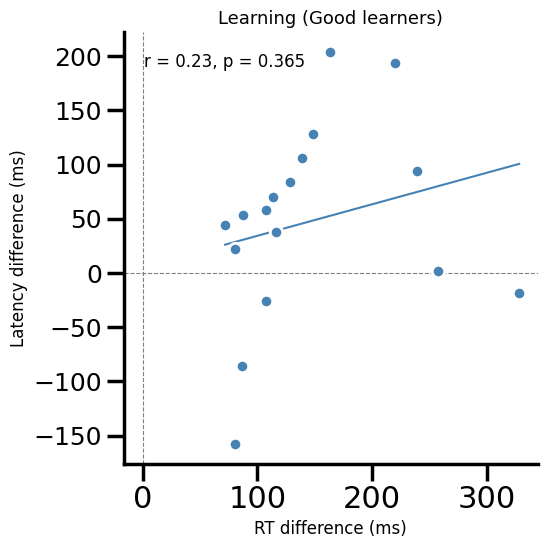

Pearson r = 0.235, p = 0.3646


In [115]:
# Correlation
x = np.asarray(good_rt_diff['learning'], dtype=float)
y = np.asarray(good_latency_diff['learning'], dtype=float)
mask = ~np.isnan(x) & ~np.isnan(y)   # rows where BOTH are present
r, p = stat.pearsonr(x[mask], y[mask])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x[mask], y[mask], 
           color='steelblue', edgecolors='white', s=80, zorder=3)

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Regression line
m, b = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5)

# Annotate correlation
ax.text(0.05, 0.92, f'r = {r:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=12)

ax.set_xlabel('RT difference (ms)', fontsize=12)
ax.set_ylabel('Latency difference (ms)', fontsize=12)
ax.set_title('Learning (Good learners)', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.4f}")

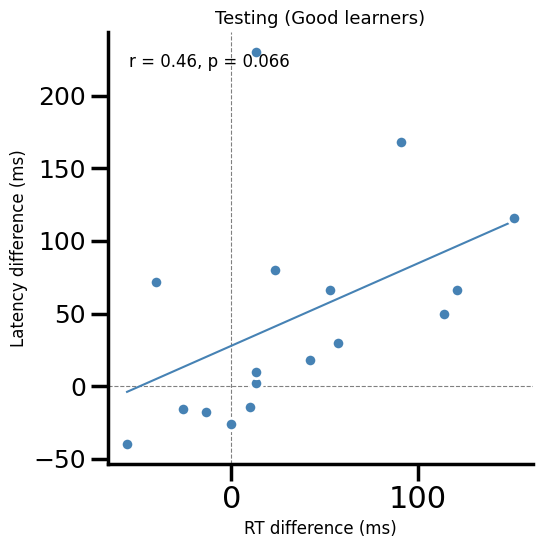

Pearson r = 0.455, p = 0.0663


In [116]:
# Correlation
x = np.asarray(good_rt_diff['testing'], dtype=float)
y = np.asarray(good_latency_diff['testing'], dtype=float)
mask = ~np.isnan(x) & ~np.isnan(y)   # rows where BOTH are present
r, p = stat.pearsonr(x[mask], y[mask])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x[mask], y[mask], 
           color='steelblue', edgecolors='white', s=80, zorder=3)

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Regression line
m, b = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5)

# Annotate correlation
ax.text(0.05, 0.92, f'r = {r:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=12)

ax.set_xlabel('RT difference (ms)', fontsize=12)
ax.set_ylabel('Latency difference (ms)', fontsize=12)
ax.set_title('Testing (Good learners)', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.4f}")

### poor learners

In [117]:
poor_rt_diff =rt_diff_phases[~rt_diff_phases['ID'].isin(valid_group_ids)]
poor_latency_diff = ind_latency_diff[~ind_latency_diff['subject'].isin(valid_group_ids)]

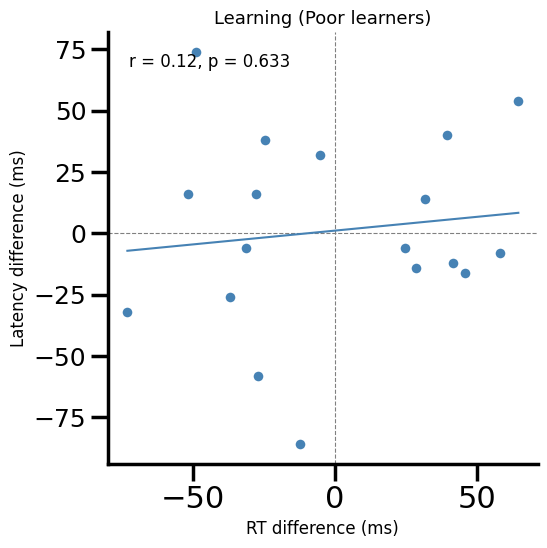

Pearson r = 0.121, p = 0.6331


In [118]:
# Correlation
x = np.asarray(poor_rt_diff['learning'], dtype=float)
y = np.asarray(poor_latency_diff['learning'], dtype=float)
mask = ~np.isnan(x) & ~np.isnan(y)   # rows where BOTH are present
r, p = stat.pearsonr(x[mask], y[mask])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x[mask], y[mask], 
           color='steelblue', edgecolors='white', s=80, zorder=3)

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Regression line
m, b = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5)

# Annotate correlation
ax.text(0.05, 0.92, f'r = {r:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=12)

ax.set_xlabel('RT difference (ms)', fontsize=12)
ax.set_ylabel('Latency difference (ms)', fontsize=12)
ax.set_title('Learning (Poor learners)', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.4f}")

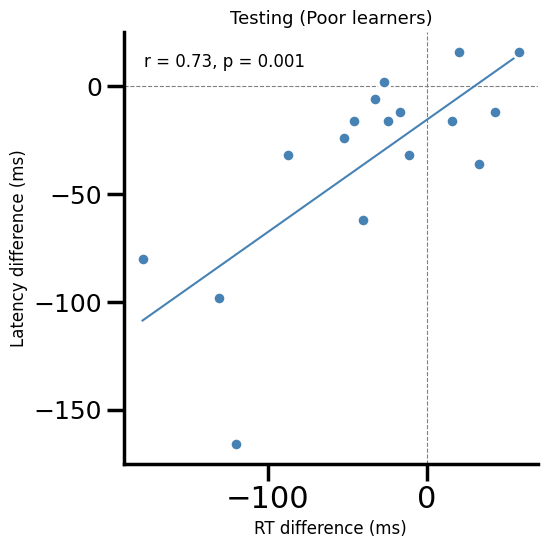

Pearson r = 0.732, p = 0.0008


In [119]:
# Correlation
x = np.asarray(poor_rt_diff['testing'], dtype=float)
y = np.asarray(poor_latency_diff['testing'], dtype=float)
mask = ~np.isnan(x) & ~np.isnan(y)   # rows where BOTH are present
r, p = stat.pearsonr(x[mask], y[mask])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x[mask], y[mask], 
           color='steelblue', edgecolors='white', s=80, zorder=3)

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Regression line
m, b = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5)

# Annotate correlation
ax.text(0.05, 0.92, f'r = {r:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=12)

ax.set_xlabel('RT difference (ms)', fontsize=12)
ax.set_ylabel('Latency difference (ms)', fontsize=12)
ax.set_title('Testing (Poor learners)', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.4f}")

# object effects

statistical test result in R

In [120]:
target_info = train.groupby('ID')['TargetID'].unique().reset_index()
target_info.columns = ['ID', 'TargetIDs']

# Add learner group label
target_info['LearnerGroup'] = target_info['ID'].apply(
    lambda x: 'good' if x in valid_group_ids else 'poor'
)

# Also get the *frequent* target specifically
# TargetCondition == 'frequent' rows should all share the same TargetID per subject
frequent_target = (train[train['TargetCondition'] == 'frequent']
                   .groupby('ID')['TargetID']
                   .unique()
                   .reset_index())
frequent_target.columns = ['ID', 'FrequentTargetID']

target_info = target_info.merge(frequent_target, on='ID')
target_info['FrequentTargetID'] = target_info['FrequentTargetID'].apply(lambda x: x[0])

# Summary: count of each FrequentTargetID within each group
print("── FrequentTargetID counts by group ──")
summary = (target_info.groupby(['LearnerGroup', 'FrequentTargetID'])
           .size()
           .reset_index(name='count'))
print(summary.to_string(index=False))

── FrequentTargetID counts by group ──
LearnerGroup  FrequentTargetID  count
        good                 1      3
        good                 2      5
        good                 3      3
        good                 4      7
        poor                 1      6
        poor                 2      5
        poor                 3      5
        poor                 4      2


In [121]:
train_copy = train.copy()
test_copy  = test.copy()

train_copy['Phase'] = 'learning'
test_copy['Phase']  = 'testing'
 
df = pd.concat([train_copy, test_copy], ignore_index=True)
df['LearnerGroup'] = df['ID'].apply(
    lambda x: 'good' if x in valid_group_ids else 'poor'
)
df = df.merge(target_info[['ID', 'FrequentTargetID']], on='ID', how='left')
rt_means = df.groupby(['ID', 'Phase', 'TargetCondition', 'FrequentTargetID'])['RT'].mean().reset_index()

In [122]:
# rt_means.to_csv('C:/Experiments/object_learning_EEG/ERP_analysis/rt_means.csv', index=False)

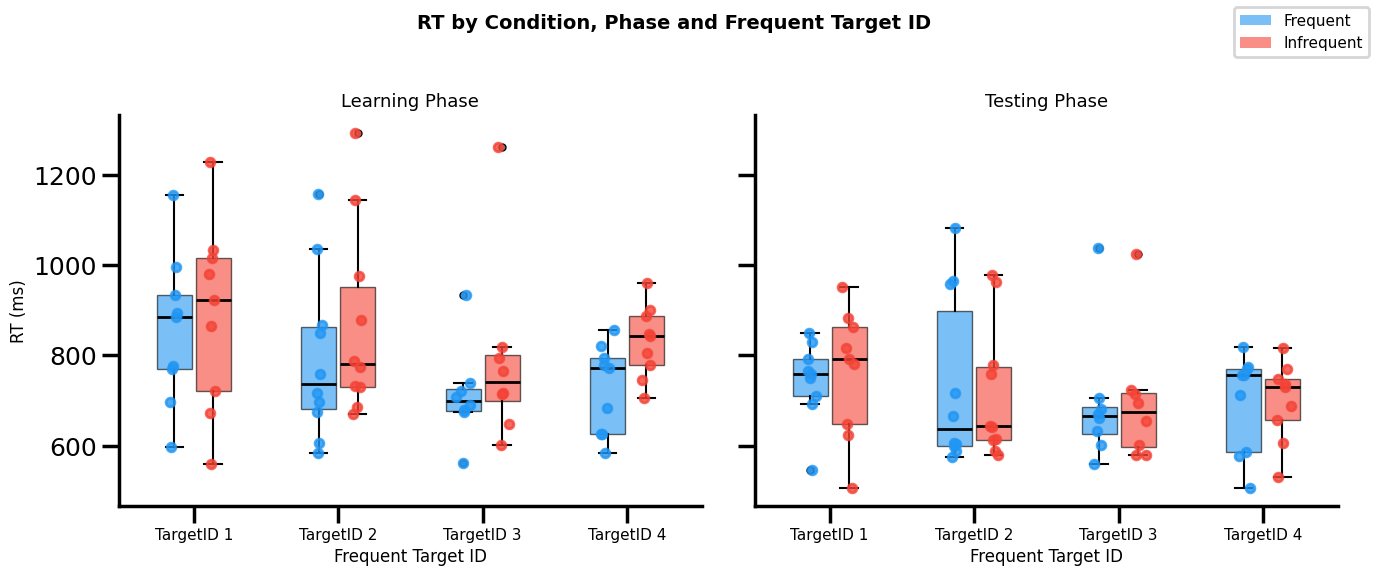

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

phases = ['learning', 'testing']
colors = {'frequent': '#2196F3', 'infrequent': '#F44336'}
target_ids = sorted(rt_means['FrequentTargetID'].unique())
n_targets = len(target_ids)

for ax, phase in zip(axes, phases):
    phase_data = rt_means[rt_means['Phase'] == phase]
    
    # Position setup: 2 boxes per targetID, with gap between groups
    group_width = 0.35
    gap = 0.6
    positions_freq   = [i * (2 * group_width + gap) + 1               for i in range(n_targets)]
    positions_infreq = [i * (2 * group_width + gap) + 1 + group_width for i in range(n_targets)]
    
    for positions, cond in zip([positions_freq, positions_infreq], 
                                ['frequent', 'infrequent']):
        data_per_target = [
            phase_data[(phase_data['FrequentTargetID'] == tid) & 
                       (phase_data['TargetCondition']  == cond)]['RT'].values
            for tid in target_ids
        ]
        
        bp = ax.boxplot(
            data_per_target,
            positions=positions,
            patch_artist=True,
            widths=group_width * 0.9,
            boxprops=dict(facecolor=colors[cond], alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=5)
        )
        
        # Overlay individual points
        for pos, data in zip(positions, data_per_target):
            x = np.random.normal(pos, 0.03, size=len(data))
            ax.scatter(x, data, color=colors[cond], alpha=0.8, s=40, zorder=3)
    
    # X ticks at center of each group
    group_centers = [(f + i) / 2 for f, i in zip(positions_freq, positions_infreq)]
    ax.set_xticks(group_centers)
    ax.set_xticklabels([f'TargetID {tid}' for tid in target_ids], fontsize=11)
    ax.set_title(f'{phase.capitalize()} Phase', fontsize=13)
    ax.set_xlabel('Frequent Target ID', fontsize=12)
    sns.despine(ax=ax)

axes[0].set_ylabel('RT (ms)', fontsize=12)

# Legend
legend_elements = [Patch(facecolor=colors['frequent'],   alpha=0.6, label='Frequent'),
                   Patch(facecolor=colors['infrequent'], alpha=0.6, label='Infrequent')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.suptitle('RT by Condition, Phase and Frequent Target ID', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [124]:
poor_rt_means = rt_means[rt_means['ID'].isin(invalid_group_ids)]

In [125]:
# poor_rt_means.to_csv('C:/Experiments/object_learning_EEG/ERP_analysis/poor_rt_means.csv', index=False)

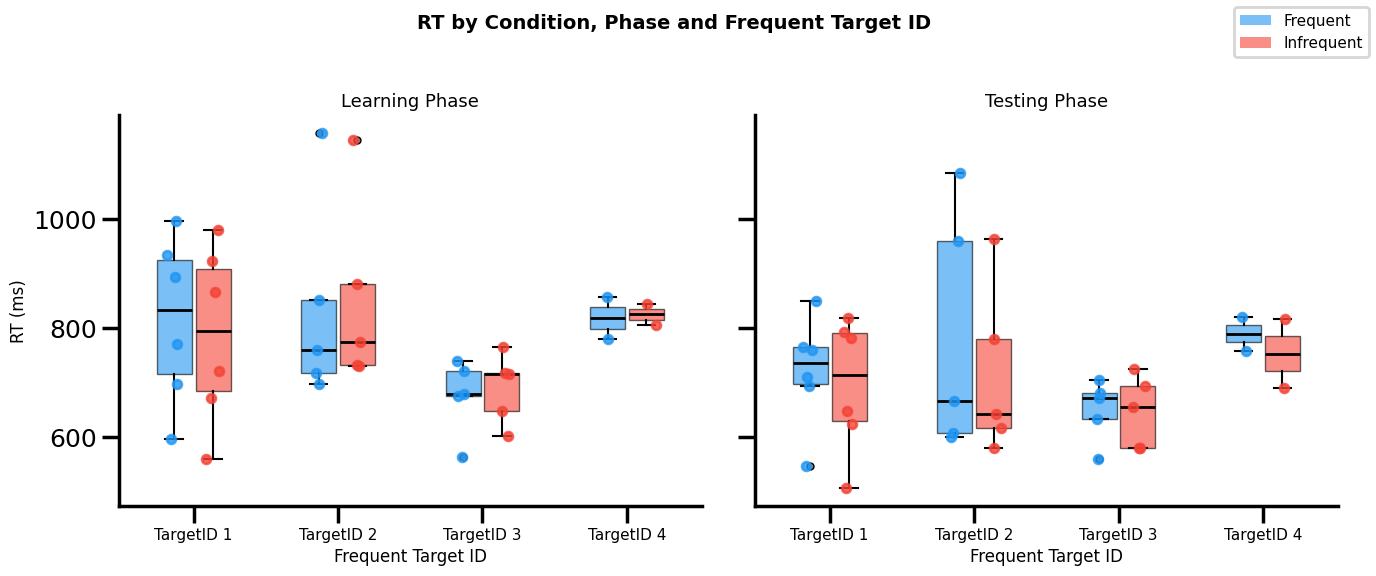

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

phases = ['learning', 'testing']
colors = {'frequent': '#2196F3', 'infrequent': '#F44336'}
target_ids = sorted(poor_rt_means['FrequentTargetID'].unique())
n_targets = len(target_ids)

for ax, phase in zip(axes, phases):
    phase_data = poor_rt_means[poor_rt_means['Phase'] == phase]
    
    # Position setup: 2 boxes per targetID, with gap between groups
    group_width = 0.35
    gap = 0.6
    positions_freq   = [i * (2 * group_width + gap) + 1               for i in range(n_targets)]
    positions_infreq = [i * (2 * group_width + gap) + 1 + group_width for i in range(n_targets)]
    
    for positions, cond in zip([positions_freq, positions_infreq], 
                                ['frequent', 'infrequent']):
        data_per_target = [
            phase_data[(phase_data['FrequentTargetID'] == tid) & 
                       (phase_data['TargetCondition']  == cond)]['RT'].values
            for tid in target_ids
        ]
        
        bp = ax.boxplot(
            data_per_target,
            positions=positions,
            patch_artist=True,
            widths=group_width * 0.9,
            boxprops=dict(facecolor=colors[cond], alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=5)
        )
        
        # Overlay individual points
        for pos, data in zip(positions, data_per_target):
            x = np.random.normal(pos, 0.03, size=len(data))
            ax.scatter(x, data, color=colors[cond], alpha=0.8, s=40, zorder=3)
    
    # X ticks at center of each group
    group_centers = [(f + i) / 2 for f, i in zip(positions_freq, positions_infreq)]
    ax.set_xticks(group_centers)
    ax.set_xticklabels([f'TargetID {tid}' for tid in target_ids], fontsize=11)
    ax.set_title(f'{phase.capitalize()} Phase', fontsize=13)
    ax.set_xlabel('Frequent Target ID', fontsize=12)
    sns.despine(ax=ax)

axes[0].set_ylabel('RT (ms)', fontsize=12)

# Legend
legend_elements = [Patch(facecolor=colors['frequent'],   alpha=0.6, label='Frequent'),
                   Patch(facecolor=colors['infrequent'], alpha=0.6, label='Infrequent')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.suptitle('RT by Condition, Phase and Frequent Target ID', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Linear mixed effect model

## Latency

In [127]:
ind_latency = ind_latency.rename(columns={'subject': 'ID', 'phase': 'Phase',
                           'frequency': 'TargetCondition', 'rt': 'RT'}).copy()

# harmonize the label vocabularies to match the latency frame
ind_latency['Phase']     = ind_latency['Phase'].map({'Train': 'learning', 'Test': 'testing'})
ind_latency['TargetCondition'] = ind_latency['TargetCondition'].map({'Frequent': 'frequent',
                                       'Infrequent': 'infrequent'})

rt_latency = rt_diff.merge(ind_latency, on=['ID', 'Phase', 'TargetCondition'], how='inner')
rt_latency = rt_latency[['ID', 'Phase', 'TargetCondition', 'RT', 'latency']]
rt_latency

,ID,Phase,TargetCondition,RT,latency
0,2,learning,frequent,583.358923,356.0
1,2,learning,infrequent,670.896499,410.0
2,2,testing,frequent,575.047717,402.0
3,2,testing,infrequent,588.239497,404.0
4,3,learning,frequent,720.236205,300.0
...,...,...,...,...,...
139,48,testing,infrequent,769.396100,438.0
140,49,learning,frequent,596.966519,340.0
141,49,learning,infrequent,560.267390,314.0
142,49,testing,frequent,546.074534,338.0


In [128]:
rt_latency.to_csv('C:/Experiments/object_learning_EEG/ERP_analysis/rt_latency.csv', index=False)

## RT

In [129]:
train_copy = train.copy()
test_copy  = test.copy()

train_copy['Phase'] = 'learning'
test_copy['Phase']  = 'testing'
 
df = pd.concat([train_copy, test_copy], ignore_index=True)
df['LearnerGroup'] = df['ID'].apply(
    lambda x: 'good' if x in valid_group_ids else 'poor'
)
df = df.merge(target_info[['ID', 'FrequentTargetID']], on='ID', how='left')

In [130]:
df

,index,ID,TrialNumber,BlockNumber,TargetID,TargetLocation,TargetCondition,Accuracy,RT,phase,AnalysisBlock,Phase,LearnerGroup,FrequentTargetID
0,0,10,34,1,1,1,infrequent,1,1071.7585,train,1.0,learning,poor,2
1,1,10,35,1,2,4,frequent,1,492.1108,train,1.0,learning,poor,2
2,2,10,36,1,4,3,infrequent,1,609.0583,train,1.0,learning,poor,2
3,3,10,38,2,2,2,frequent,1,1082.2648,train,1.0,learning,poor,2
4,4,10,39,2,4,1,infrequent,1,584.6471,train,1.0,learning,poor,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36316,24235,7,841,36,2,1,infrequent,1,579.2988,test,2.0,testing,poor,3
36317,24236,7,842,36,2,4,infrequent,1,1148.3449,test,2.0,testing,poor,3
36318,24237,7,843,36,3,3,frequent,1,719.4029,test,2.0,testing,poor,3
36319,24238,7,844,36,4,2,infrequent,1,698.1550,test,2.0,testing,poor,3


In [131]:
# Treatment (dummy) coding — reference levels:
#   TargetCondition : 'frequent'  (effect of interest is infrequent > frequent)
#   Phase           : 'learning'
#   LearnerGroup    : 'good'
df['TargetCondition'] = pd.Categorical(df['TargetCondition'],
                                        categories=['frequent', 'infrequent'])
df['Phase']           = pd.Categorical(df['Phase'],
                                        categories=['learning', 'testing'])
df['LearnerGroup']    = pd.Categorical(df['LearnerGroup'],
                                        categories=['good', 'poor'])
df['FrequentTargetID'] = pd.Categorical(df['FrequentTargetID'])

RT ~ targetCondition * phase * learnerGroup * frequentTargetID + (1 + TargetCondition|ID)

In [132]:
# Fixed effects:
#   TargetCondition            — frequent vs infrequent
#   Phase                      — learning vs testing
#   LearnerGroup               — good vs poor
#   … and all 2-way and 3-way interactions
#
# Random effects:
#   (1 | ID)                   — random intercept per participant (baseline RT)
#   (0 + C(TargetCondition) | ID) — random slope: each person's own freq/infreq effect
#
# The random slope lets each participant have their own learning effect size,
# which directly addresses the "person-to-person" question.
 
model = smf.mixedlm(
    "RT ~ TargetCondition * Phase * LearnerGroup * FrequentTargetID",
    data=df,
    groups=df["ID"],                          # random intercept per subject
    re_formula="~TargetCondition"                     # random slope for condition
)
 
result = model.fit(method="lbfgs")
result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                                   Mixed Linear Model Regression Results
===========================================================================================================================================
Model:                                       MixedLM                            Dependent Variable:                            RT          
No. Observations:                            36321                              Method:                                        REML        
No. Groups:                                  36                                 Scale:                                         70845.3156  
Min. group size:                             763                                Log-Likelihood:                                -254348.8013
Max. group size:                             1222                               Converged:                                     Yes         
Mean group size:                             1008.9                                                                                        
-------------------------------------------------------------------------------------------------------------------------------------------
                                                                                            Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                   931.650   80.170 11.621 0.000  774.520 1088.780
TargetCondition[T.infrequent]                                                               156.662   30.531  5.131 0.000   96.822  216.502
Phase[T.testing]                                                                           -138.093   16.191 -8.529 0.000 -169.826 -106.359
LearnerGroup[T.poor]                                                                       -115.058   98.228 -1.171 0.241 -307.582   77.466
FrequentTargetID[T.2]                                                                      -178.632  101.452 -1.761 0.078 -377.474   20.210
FrequentTargetID[T.3]                                                                      -157.986  113.414 -1.393 0.164 -380.272   64.301
FrequentTargetID[T.4]                                                                      -231.367   95.858 -2.414 0.016 -419.245  -43.490
TargetCondition[T.infrequent]:Phase[T.testing]                                              -50.336   21.050 -2.391 0.017  -91.593   -9.078
TargetCondition[T.infrequent]:LearnerGroup[T.poor]                                         -185.073   37.530 -4.931 0.000 -258.630 -111.517
Phase[T.testing]:LearnerGroup[T.poor]                                                        40.570   20.226  2.006 0.045    0.928   80.213
TargetCondition[T.infrequent]:FrequentTargetID[T.2]                                         -29.664   38.867 -0.763 0.445 -105.842   46.513
TargetCondition[T.infrequent]:FrequentTargetID[T.3]                                          24.026   43.371  0.554 0.580  -60.980  109.031
TargetCondition[T.infrequent]:FrequentTargetID[T.4]                                         -25.536   36.686 -0.696 0.486  -97.439   46.367
Phase[T.testing]:FrequentTargetID[T.2]                                                       75.150   20.853  3.604 0.000   34.279  116.021
Phase[T.testing]:FrequentTargetID[T.3]                                                      131.509   23.160  5.678 0.000   86.117  176.901
Phase[T.testing]:FrequentTargetID[T.4]                                                      108.732   19.785  5.496 0.000   69.954  147.509
LearnerGroup[T.poor]:FrequentTargetID[T.2]                                                  199.131  131.813  1.511 0.131  -59.217  457.480
LearnerGroup[T.poor]:FrequentTargetID[T.3]                                        

RT diff ~ phase * frequentTargetID + (1|ID)

In [133]:
rt_diff = (df
           .groupby(['ID', 'Phase', 'TargetCondition'])['RT']
           .mean()
           .reset_index())

# Pivot to wide format then compute difference
rt_diff_wide = rt_diff.pivot_table(index=['ID', 'Phase'], 
                                    columns='TargetCondition', 
                                    values='RT').reset_index()
rt_diff_wide.columns.name = None
rt_diff_wide['RT_diff'] = rt_diff_wide['infrequent'] - rt_diff_wide['frequent']

# Merge in FrequentTargetID and LearnerGroup
rt_diff_wide = rt_diff_wide.merge(target_info[['ID', 'FrequentTargetID']], on='ID')
rt_diff_wide['LearnerGroup'] = rt_diff_wide['ID'].apply(
    lambda x: 'good' if x in valid_group_ids else 'poor'
)

rt_diff_wide['Phase'] = pd.Categorical(rt_diff_wide['Phase'], 
                                        categories=['learning', 'testing'])
rt_diff_wide['FrequentTargetID'] = pd.Categorical(
    rt_diff_wide['FrequentTargetID'], 
    categories=[1, 2, 3, 4]  # 1 is reference
)

model2 = smf.mixedlm(
    "RT_diff ~ Phase * C(FrequentTargetID)",
    data=rt_diff_wide,
    groups=rt_diff_wide["ID"]
)

result2 = model2.fit(method="lbfgs")
print(result2.summary())

                          Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            RT_diff  
No. Observations:             72                 Method:                        REML     
No. Groups:                   36                 Scale:                         3293.7517
Min. group size:              2                  Log-Likelihood:                -376.9887
Max. group size:              2                  Converged:                     Yes      
Mean group size:              2.0                                                        
-----------------------------------------------------------------------------------------
                                           Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------------------------------
Intercept                                   32.830   27.458  1.196 0.232  -20.987  86.648
Phase[T.testing]                    

C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\2385359321.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['ID', 'Phase', 'TargetCondition'])['RT']
C:\Users\dartuser\AppData\Local\Temp\ipykernel_23656\2385359321.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rt_diff_wide = rt_diff.pivot_table(index=['ID', 'Phase'],


RT ~ targetCondition * phase * frequentTargetID + (1|ID)

In [134]:
df['TargetCondition'] = pd.Categorical(df['TargetCondition'],
                                        categories=['frequent', 'infrequent'])
df['Phase']           = pd.Categorical(df['Phase'],
                                        categories=['learning', 'testing'])
df['FrequentTargetID'] = pd.Categorical(df['FrequentTargetID'],
                                        categories=[1, 2, 3, 4])
        
model3 = smf.mixedlm(
    "RT ~ TargetCondition * Phase * C(FrequentTargetID)",
    data=df,
    groups=df["ID"],
    re_formula="~TargetCondition"
)
result3 = model3.fit(method="lbfgs")
result3.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                          Mixed Linear Model Regression Results
=========================================================================================================================
Model:                                 MixedLM                      Dependent Variable:                      RT          
No. Observations:                      36321                        Method:                                  REML        
No. Groups:                            36                           Scale:                                   71048.5744  
Min. group size:                       763                          Log-Likelihood:                          -254490.0059
Max. group size:                       1222                         Converged:                               Yes         
Mean group size:                       1008.9                                                                            
-------------------------------------------------------------------------------------------------------------------------
                                                                          Coef.   Std.Err.    z    P>|z|  [0.025   0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                                 855.449   46.520  18.389 0.000  764.272 946.626
TargetCondition[T.infrequent]                                              33.284   23.165   1.437 0.151  -12.118  78.686
Phase[T.testing]                                                         -112.098    9.718 -11.535 0.000 -131.145 -93.050
C(FrequentTargetID)[T.2]                                                  -60.365   64.124  -0.941 0.347 -186.046  65.316
C(FrequentTargetID)[T.3]                                                 -142.869   67.791  -2.107 0.035 -275.738 -10.000
C(FrequentTargetID)[T.4]                                                 -128.898   65.795  -1.959 0.050 -257.854   0.057
TargetCondition[T.infrequent]:Phase[T.testing]                            -14.175   12.528  -1.131 0.258  -38.729  10.379
TargetCondition[T.infrequent]:C(FrequentTargetID)[T.2]                     37.524   31.964   1.174 0.240  -25.124 100.172
TargetCondition[T.infrequent]:C(FrequentTargetID)[T.3]                     40.830   33.696   1.212 0.226  -25.213 106.874
TargetCondition[T.infrequent]:C(FrequentTargetID)[T.4]                     68.011   32.806   2.073 0.038    3.713 132.310
Phase[T.testing]:C(FrequentTargetID)[T.2]                                  51.414   13.378   3.843 0.000   25.193  77.634
Phase[T.testing]:C(FrequentTargetID)[T.3]                                  92.637   13.984   6.625 0.000   65.230 120.045
Phase[T.testing]:C(FrequentTargetID)[T.4]                                  82.776   13.850   5.976 0.000   55.630 109.922
TargetCondition[T.infrequent]:Phase[T.testing]:C(FrequentTargetID)[T.2]   -73.900   17.308  -4.270 0.000 -107.823 -39.976
TargetCondition[T.infrequent]:Phase[T.testing]:C(FrequentTargetID)[T.3]   -56.239   18.045  -3.117 0.002  -91.606 -20.872
TargetCondition[T.infrequent]:Phase[T.testing]:C(FrequentTargetID)[T.4]   -85.263   17.879  -4.769 0.000 -120.306 -50.220
Group Var                                                               19052.035   18.067                               
Group x TargetCondition[T.infrequent] Cov                               -1176.308    6.102                               
TargetCondition[T.infrequent] Var                                        3983.159    4.026                               
=========================================================================================================================

"""